# Test 2 Data Analysis - Strawberry Monitoring System

**Duration:** February 13-16, 2026 (2.5 days)  
**Data Collected:**
- 67 photos (every 60 minutes)
- 267 sensor data cycles from 3 ESP32 nodes
- Environmental monitoring: Temperature, Humidity, TVOC, eCO2, MQ3 (alcohol sensor)

This notebook analyzes the autonomous data collection from the strawberry ripeness monitoring test.

## 1. Import Required Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from datetime import datetime
import os

# Set matplotlib style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

### Mold Detection Reference

Define the timestamp when visible mold was first observed on the strawberries (from photo evidence).

In [2]:
# MOLD DETECTION TIMESTAMP
# Update this with the actual timestamp from the photo showing visible mold
# Format: 'YYYY-MM-DD HH:MM:SS'
# Test 2 ran from: 2026-02-13 17:32 to 2026-02-16 12:03

MOLD_DETECTED_TIME = '2026-02-14 21:43:34'  # ⚠️ UPDATE THIS with actual photo timestamp

# Convert to datetime
mold_timestamp = pd.to_datetime(MOLD_DETECTED_TIME)
print(f"⚠️ Mold Detection Marker Set: {mold_timestamp}")
print(f"   This red line will appear on sensor data graphs")
print(f"   Update MOLD_DETECTED_TIME variable with actual photo timestamp")

⚠️ Mold Detection Marker Set: 2026-02-14 21:43:34
   This red line will appear on sensor data graphs
   Update MOLD_DETECTED_TIME variable with actual photo timestamp


## 2. Load Test 2 Sensor Data

In [3]:
# Load the sensor data
data_path = 'RaspberryPiData/test2/sensor_data/unified_sensor_data.csv'
df = pd.read_csv(data_path)

# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Display basic information
print(f"Total records: {len(df)}")
print(f"Time range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"Duration: {df['timestamp'].max() - df['timestamp'].min()}")
print(f"\nColumns: {list(df.columns)}")

# Display first few rows
df.head(10)

Total records: 267
Time range: 2026-02-13 17:35:55 to 2026-02-16 11:53:52
Duration: 2 days 18:17:57

Columns: ['timestamp', 'cycle_number', 'master_temp', 'master_hum', 'master_tvoc', 'master_eco2', 'master_mq3_ppm', 'node1_temp', 'node1_hum', 'node1_tvoc', 'node1_eco2', 'node1_mq3_ppm', 'node2_temp', 'node2_hum', 'node2_tvoc', 'node2_eco2', 'node2_mq3_ppm']


,timestamp,cycle_number,master_temp,master_hum,master_tvoc,master_eco2,master_mq3_ppm,node1_temp,node1_hum,node1_tvoc,node1_eco2,node1_mq3_ppm,node2_temp,node2_hum,node2_tvoc,node2_eco2,node2_mq3_ppm
0,2026-02-13 17:35:55,1,25.400000,36.000000,31,538,0.532876,29.500000,68.199997,0,915,52.318192,24.900000,74.400002,0,400,0.881722
1,2026-02-13 17:50:55,2,25.700001,37.599998,9,414,0.264714,29.700001,69.900002,214,1767,100.125298,24.900000,75.000000,0,400,3.116747
2,2026-02-13 18:05:43,3,25.700001,33.799999,11,435,0.302453,33.400002,76.300003,196,1666,92.851089,26.299999,77.099998,0,400,4.086394
3,2026-02-13 18:20:31,4,25.500000,34.900002,2,412,0.068282,34.400002,74.599998,166,1499,92.106949,26.900000,77.900002,0,400,4.141580
4,2026-02-13 18:35:24,5,24.600000,34.500000,8,404,0.051938,34.700001,69.199997,163,1490,84.186005,27.100000,75.599998,0,400,4.598322
5,2026-02-13 18:50:19,6,25.200001,32.099998,1,415,0.047018,34.900002,72.000000,165,1488,82.108353,27.299999,76.199997,0,400,5.794143
6,2026-02-13 19:05:16,7,25.799999,31.100000,11,408,0.047018,35.500000,68.800003,167,1487,88.808350,27.700001,75.699997,0,400,5.794143
7,2026-02-13 19:20:13,8,26.000000,30.700001,3,403,0.026292,35.599998,69.800003,165,1467,85.590530,28.000000,75.000000,0,400,6.488019
8,2026-02-13 19:35:09,9,26.200001,29.900000,26,438,0.042359,35.799999,68.900002,163,1504,91.366837,28.200001,74.199997,0,400,6.488019
9,2026-02-13 19:50:07,10,26.400000,29.500000,11,409,0.026292,36.000000,71.599998,165,1503,91.736427,28.400000,74.699997,0,400,6.205036


## 3. Data Statistics Summary

In [4]:
# Display statistics for all sensor readings
df.describe()

,timestamp,cycle_number,master_temp,master_hum,master_tvoc,master_eco2,master_mq3_ppm,node1_temp,node1_hum,node1_tvoc,node1_eco2,node1_mq3_ppm,node2_temp,node2_hum,node2_tvoc,node2_eco2,node2_mq3_ppm
count,267,267.000000,267.000000,267.000000,267.000000,267.000000,242.000000,267.000000,267.000000,267.000000,267.000000,258.000000,267.000000,267.000000,267.000000,267.000000,258.000000
mean,2026-02-15 02:44:39.689138688,134.000000,23.735206,26.942697,18.344569,440.805243,1.671933,34.249438,70.272285,3292.599251,12593.689139,670.437895,26.227715,77.723970,288.505618,5198.955056,46.310757
min,2026-02-13 17:35:55,1.000000,19.400000,21.299999,0.000000,400.000000,0.011815,29.500000,65.300003,0.000000,400.000000,30.787790,22.900000,70.000000,0.000000,400.000000,0.881722
25%,2026-02-14 10:09:59,67.500000,21.150001,24.250000,4.000000,406.000000,0.088741,32.799999,67.950001,771.000000,5614.500000,303.905212,24.200001,74.300003,0.000000,1053.500000,20.494489
50%,2026-02-15 02:44:41,134.000000,23.400000,26.299999,8.000000,413.000000,0.685128,34.400002,69.800003,3850.000000,14302.000000,651.545380,26.000000,78.900002,319.000000,5493.000000,42.632568
75%,2026-02-15 19:19:15,200.500000,26.250000,30.000000,15.000000,435.000000,1.740082,35.900002,72.149998,4976.500000,18100.000000,998.179672,28.100000,80.300003,475.500000,7963.000000,70.593655
max,2026-02-16 11:53:52,267.000000,29.900000,37.599998,204.000000,1340.000000,15.145705,38.400002,98.500000,6574.000000,23400.000000,1368.735107,30.600000,95.599998,881.000000,13572.000000,107.366966
std,NaN,77.220464,2.976606,3.394906,31.300046,99.328419,2.613182,2.114208,3.597239,2056.015798,6793.714003,389.078526,2.211908,3.967844,229.467975,3469.842888,29.350580


## 4. Temperature Analysis - All Nodes

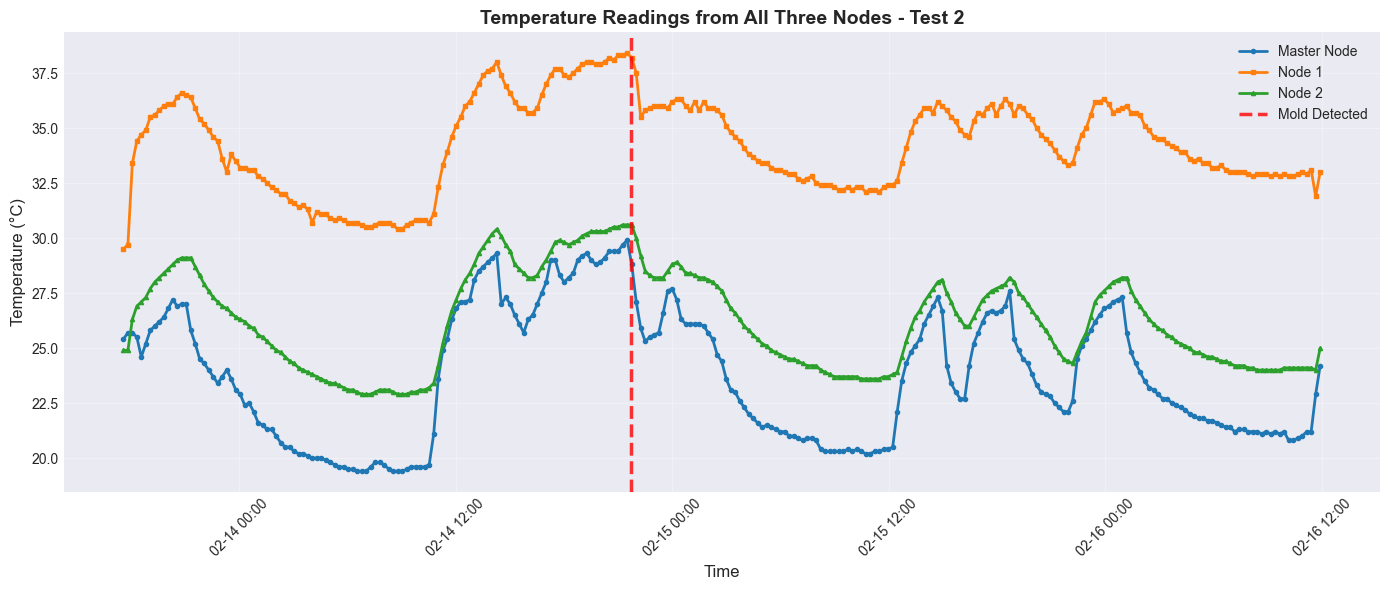

Temperature Statistics:
Master Node: 23.74°C (±2.98)
Node 1:      34.25°C (±2.11)
Node 2:      26.23°C (±2.21)


In [5]:
fig, ax = plt.subplots(figsize=(14, 6))

# Plot temperature for all three nodes
ax.plot(df['timestamp'], df['master_temp'], label='Master Node', linewidth=2, marker='o', markersize=3)
ax.plot(df['timestamp'], df['node1_temp'], label='Node 1', linewidth=2, marker='s', markersize=3)
ax.plot(df['timestamp'], df['node2_temp'], label='Node 2', linewidth=2, marker='^', markersize=3)

ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Temperature (°C)', fontsize=12)
ax.set_title('Temperature Readings from All Three Nodes - Test 2', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

# Mark mold detection time
ax.axvline(x=mold_timestamp, color='red', linestyle='--', linewidth=2.5, label='Mold Detected', alpha=0.8)

# Format x-axis to show dates nicely
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
plt.xticks(rotation=45)
ax.legend(loc='best', fontsize=10)
plt.tight_layout()
plt.show()

# Print temperature statistics
print("Temperature Statistics:")
print(f"Master Node: {df['master_temp'].mean():.2f}°C (±{df['master_temp'].std():.2f})")
print(f"Node 1:      {df['node1_temp'].mean():.2f}°C (±{df['node1_temp'].std():.2f})")
print(f"Node 2:      {df['node2_temp'].mean():.2f}°C (±{df['node2_temp'].std():.2f})")

## 5. Humidity Analysis - All Nodes

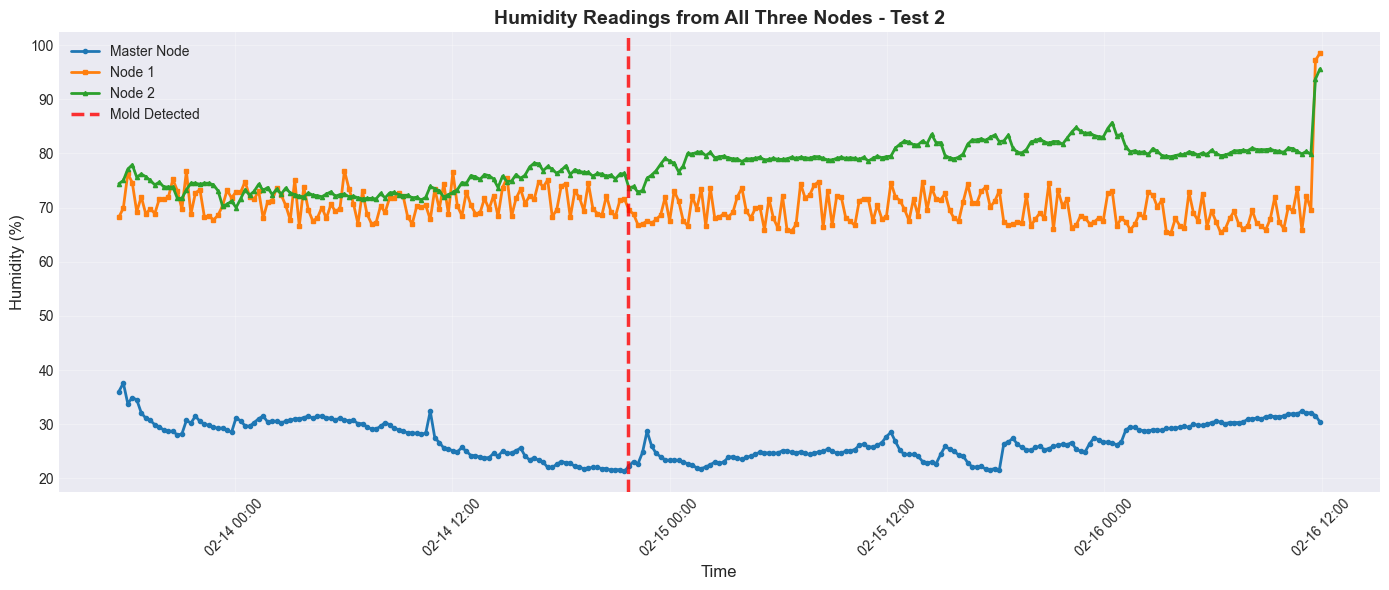

Humidity Statistics:
Master Node: 26.94% (±3.39)
Node 1:      70.27% (±3.60)
Node 2:      77.72% (±3.97)


In [6]:
fig, ax = plt.subplots(figsize=(14, 6))

# Plot humidity for all three nodes
ax.plot(df['timestamp'], df['master_hum'], label='Master Node', linewidth=2, marker='o', markersize=3, color='#1f77b4')
ax.plot(df['timestamp'], df['node1_hum'], label='Node 1', linewidth=2, marker='s', markersize=3, color='#ff7f0e')
ax.plot(df['timestamp'], df['node2_hum'], label='Node 2', linewidth=2, marker='^', markersize=3, color='#2ca02c')

ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Humidity (%)', fontsize=12)
ax.set_title('Humidity Readings from All Three Nodes - Test 2', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

# Mark mold detection time
ax.axvline(x=mold_timestamp, color='red', linestyle='--', linewidth=2.5, label='Mold Detected', alpha=0.8)

# Format x-axis
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
plt.xticks(rotation=45)
ax.legend(loc='best', fontsize=10)
plt.tight_layout()
plt.show()

# Print humidity statistics
print("Humidity Statistics:")
print(f"Master Node: {df['master_hum'].mean():.2f}% (±{df['master_hum'].std():.2f})")
print(f"Node 1:      {df['node1_hum'].mean():.2f}% (±{df['node1_hum'].std():.2f})")
print(f"Node 2:      {df['node2_hum'].mean():.2f}% (±{df['node2_hum'].std():.2f})")

## 6. Air Quality Analysis - TVOC and eCO2

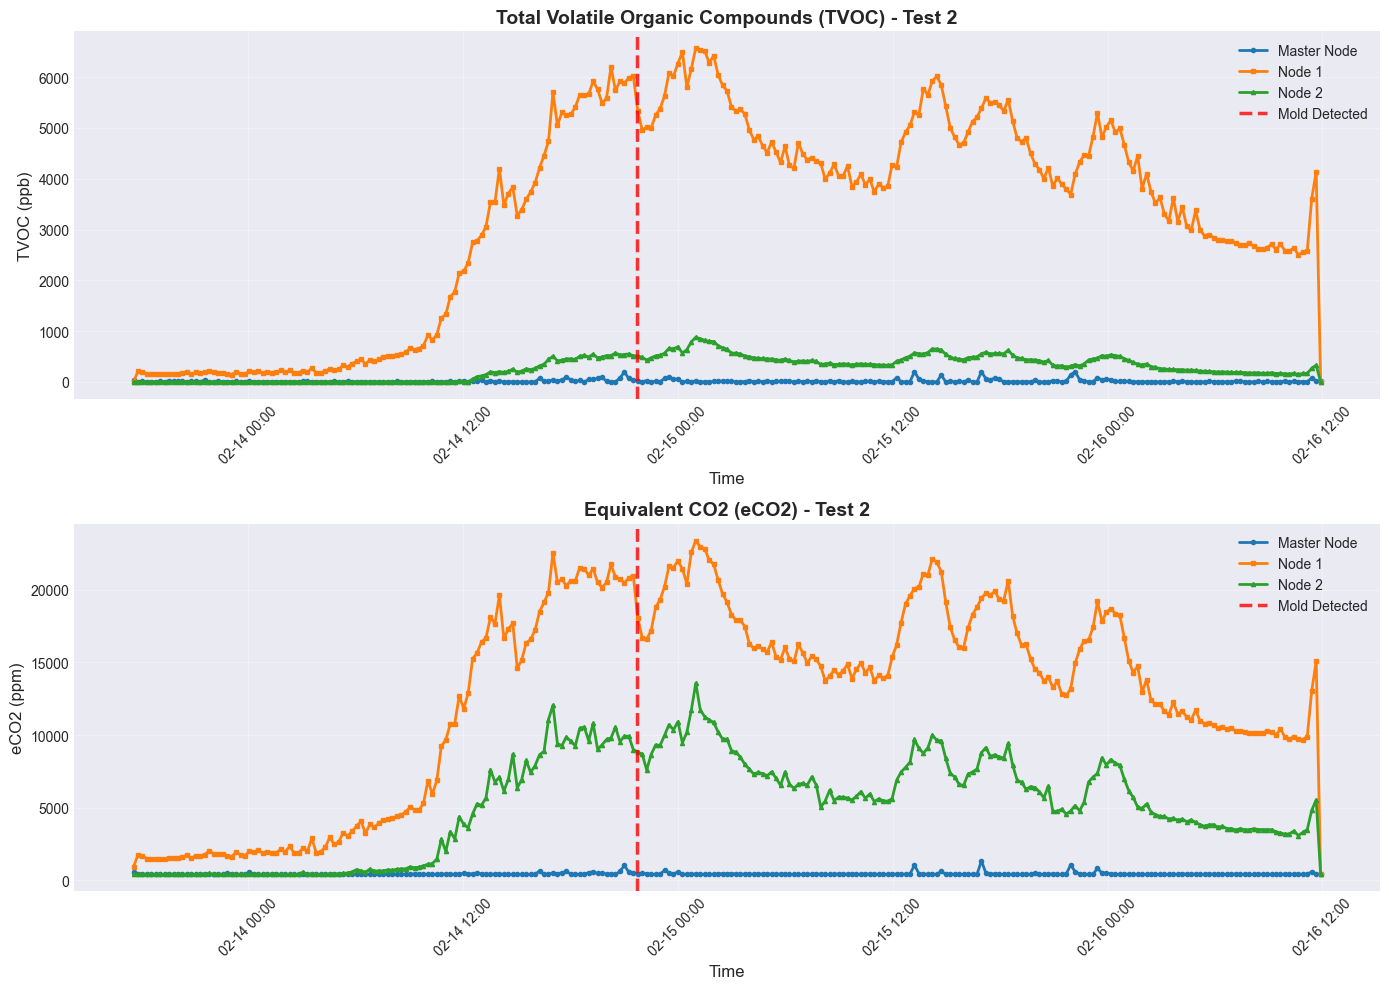

TVOC Statistics (ppb):
Master Node: 18.34 (±31.30)
Node 1:      3292.60 (±2056.02)
Node 2:      288.51 (±229.47)

eCO2 Statistics (ppm):
Master Node: 440.81 (±99.33)
Node 1:      12593.69 (±6793.71)
Node 2:      5198.96 (±3469.84)


In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# TVOC Plot
ax1.plot(df['timestamp'], df['master_tvoc'], label='Master Node', linewidth=2, marker='o', markersize=3)
ax1.plot(df['timestamp'], df['node1_tvoc'], label='Node 1', linewidth=2, marker='s', markersize=3)
ax1.plot(df['timestamp'], df['node2_tvoc'], label='Node 2', linewidth=2, marker='^', markersize=3)
ax1.set_xlabel('Time', fontsize=12)
ax1.set_ylabel('TVOC (ppb)', fontsize=12)
ax1.set_title('Total Volatile Organic Compounds (TVOC) - Test 2', fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

# Mark mold detection time
ax1.axvline(x=mold_timestamp, color='red', linestyle='--', linewidth=2.5, label='Mold Detected', alpha=0.8)
ax1.legend(loc='best', fontsize=10)

# eCO2 Plot
ax2.plot(df['timestamp'], df['master_eco2'], label='Master Node', linewidth=2, marker='o', markersize=3)
ax2.plot(df['timestamp'], df['node1_eco2'], label='Node 1', linewidth=2, marker='s', markersize=3)
ax2.plot(df['timestamp'], df['node2_eco2'], label='Node 2', linewidth=2, marker='^', markersize=3)
ax2.set_xlabel('Time', fontsize=12)
ax2.set_ylabel('eCO2 (ppm)', fontsize=12)
ax2.set_title('Equivalent CO2 (eCO2) - Test 2', fontsize=14, fontweight='bold')
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

# Mark mold detection time
ax2.axvline(x=mold_timestamp, color='red', linestyle='--', linewidth=2.5, label='Mold Detected', alpha=0.8)
ax2.legend(loc='best', fontsize=10)

plt.tight_layout()
plt.show()

# Print air quality statistics
print("TVOC Statistics (ppb):")
print(f"Master Node: {df['master_tvoc'].mean():.2f} (±{df['master_tvoc'].std():.2f})")
print(f"Node 1:      {df['node1_tvoc'].mean():.2f} (±{df['node1_tvoc'].std():.2f})")
print(f"Node 2:      {df['node2_tvoc'].mean():.2f} (±{df['node2_tvoc'].std():.2f})")
print("\neCO2 Statistics (ppm):")
print(f"Master Node: {df['master_eco2'].mean():.2f} (±{df['master_eco2'].std():.2f})")
print(f"Node 1:      {df['node1_eco2'].mean():.2f} (±{df['node1_eco2'].std():.2f})")
print(f"Node 2:      {df['node2_eco2'].mean():.2f} (±{df['node2_eco2'].std():.2f})")

## 7. MQ3 Alcohol Sensor Analysis

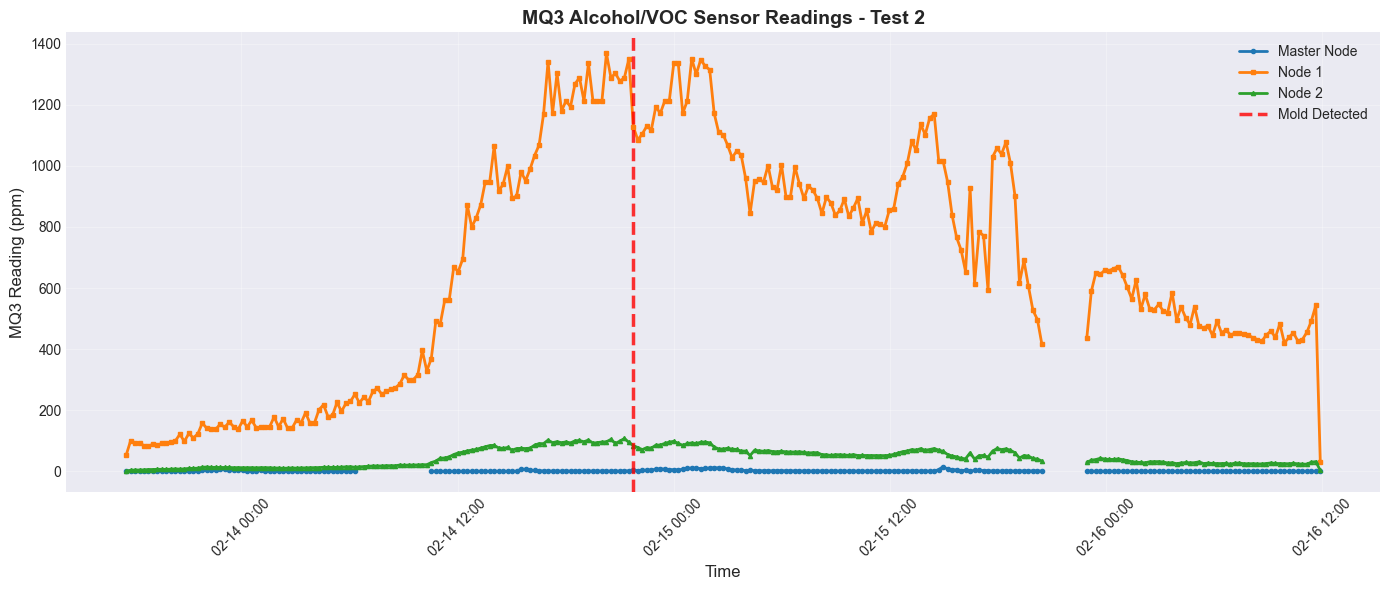

MQ3 Statistics (ppm):
Master Node: 1.67 (±2.61)
Node 1:      670.44 (±389.08)
Node 2:      46.31 (±29.35)


In [8]:
fig, ax = plt.subplots(figsize=(14, 6))

# Plot MQ3 readings for all three nodes
ax.plot(df['timestamp'], df['master_mq3_ppm'], label='Master Node', linewidth=2, marker='o', markersize=3)
ax.plot(df['timestamp'], df['node1_mq3_ppm'], label='Node 1', linewidth=2, marker='s', markersize=3)
ax.plot(df['timestamp'], df['node2_mq3_ppm'], label='Node 2', linewidth=2, marker='^', markersize=3)

ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('MQ3 Reading (ppm)', fontsize=12)
ax.set_title('MQ3 Alcohol/VOC Sensor Readings - Test 2', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

# Mark mold detection time
ax.axvline(x=mold_timestamp, color='red', linestyle='--', linewidth=2.5, label='Mold Detected', alpha=0.8)

# Format x-axis
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
plt.xticks(rotation=45)
ax.legend(loc='best', fontsize=10)
plt.tight_layout()
plt.show()

# Print MQ3 statistics
print("MQ3 Statistics (ppm):")
print(f"Master Node: {df['master_mq3_ppm'].mean():.2f} (±{df['master_mq3_ppm'].std():.2f})")
print(f"Node 1:      {df['node1_mq3_ppm'].mean():.2f} (±{df['node1_mq3_ppm'].std():.2f})")
print(f"Node 2:      {df['node2_mq3_ppm'].mean():.2f} (±{df['node2_mq3_ppm'].std():.2f})")

### 7.1 Strawberry Proximity Analysis - Node 1 & Node 2

**Node 1** (closest to strawberries) and **Node 2** (under strawberries) were positioned to detect volatile organic compounds (VOCs) released during strawberry ripening and decay. The MQ3 sensor is sensitive to alcohol and other VOCs that increase as fruit ripens and begins to ferment.

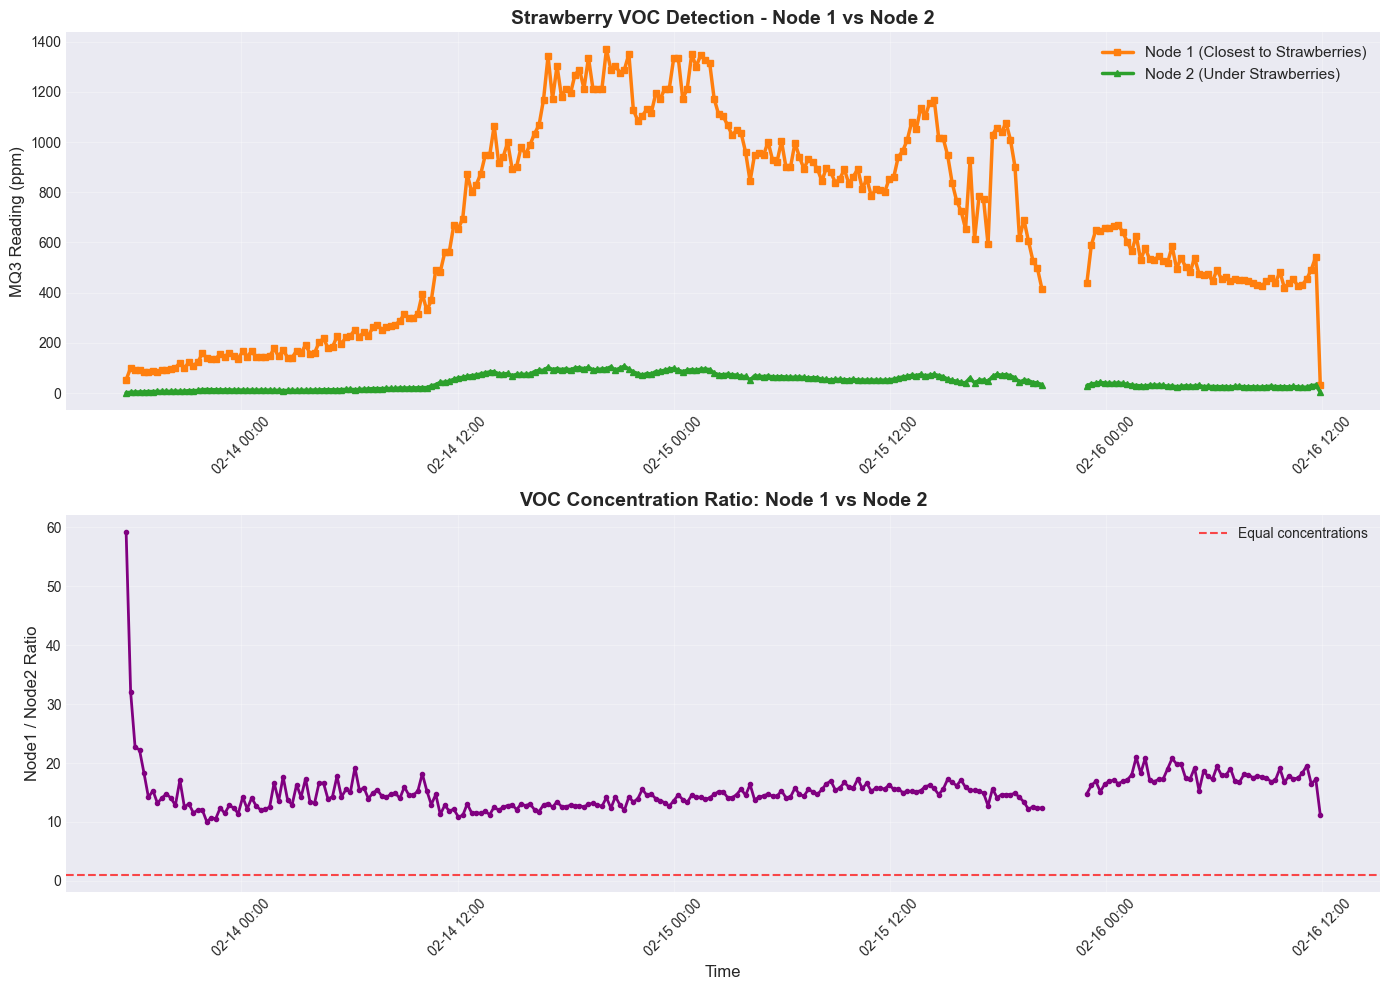

STRAWBERRY PROXIMITY VOC ANALYSIS

Node 1 (Closest to Strawberries) Statistics:
  Mean:     670.44 ppm
  Std Dev:  389.08 ppm
  Min:      30.79 ppm
  Max:      1368.74 ppm
  Range:    1337.95 ppm

Node 2 (Under Strawberries) Statistics:
  Mean:     46.31 ppm
  Std Dev:  29.35 ppm
  Min:      0.88 ppm
  Max:      107.37 ppm
  Range:    106.49 ppm

Comparative Analysis:
  Average ratio (Node1/Node2): 15.18
  Node 1 is 14.48x higher than Node 2

Trend Analysis (Linear Regression):
  Node 1 slope: nan ppm/cycle (decreasing)
  Node 2 slope: nan ppm/cycle (decreasing)

  ✓ VOC levels stable or decreasing


In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Top plot: Node 1 and Node 2 comparison
ax1.plot(df['timestamp'], df['node1_mq3_ppm'], label='Node 1 (Closest to Strawberries)', 
         linewidth=2.5, marker='s', markersize=4, color='#ff7f0e')
ax1.plot(df['timestamp'], df['node2_mq3_ppm'], label='Node 2 (Under Strawberries)', 
         linewidth=2.5, marker='^', markersize=4, color='#2ca02c')
ax1.set_ylabel('MQ3 Reading (ppm)', fontsize=12)
ax1.set_title('Strawberry VOC Detection - Node 1 vs Node 2', fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

# Bottom plot: Ratio analysis (Node1 / Node2)
# Calculate ratio to show relative VOC concentration differences
ratio = df['node1_mq3_ppm'] / (df['node2_mq3_ppm'] + 0.001)  # Add small constant to avoid division by zero
ax2.plot(df['timestamp'], ratio, linewidth=2, marker='o', markersize=3, color='purple')
ax2.axhline(y=1.0, color='red', linestyle='--', linewidth=1.5, label='Equal concentrations', alpha=0.7)
ax2.set_xlabel('Time', fontsize=12)
ax2.set_ylabel('Node1 / Node2 Ratio', fontsize=12)
ax2.set_title('VOC Concentration Ratio: Node 1 vs Node 2', fontsize=14, fontweight='bold')
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

# Statistical analysis
print("=" * 70)
print("STRAWBERRY PROXIMITY VOC ANALYSIS")
print("=" * 70)
print("\nNode 1 (Closest to Strawberries) Statistics:")
print(f"  Mean:     {df['node1_mq3_ppm'].mean():.2f} ppm")
print(f"  Std Dev:  {df['node1_mq3_ppm'].std():.2f} ppm")
print(f"  Min:      {df['node1_mq3_ppm'].min():.2f} ppm")
print(f"  Max:      {df['node1_mq3_ppm'].max():.2f} ppm")
print(f"  Range:    {df['node1_mq3_ppm'].max() - df['node1_mq3_ppm'].min():.2f} ppm")

print("\nNode 2 (Under Strawberries) Statistics:")
print(f"  Mean:     {df['node2_mq3_ppm'].mean():.2f} ppm")
print(f"  Std Dev:  {df['node2_mq3_ppm'].std():.2f} ppm")
print(f"  Min:      {df['node2_mq3_ppm'].min():.2f} ppm")
print(f"  Max:      {df['node2_mq3_ppm'].max():.2f} ppm")
print(f"  Range:    {df['node2_mq3_ppm'].max() - df['node2_mq3_ppm'].min():.2f} ppm")

print("\nComparative Analysis:")
print(f"  Average ratio (Node1/Node2): {ratio.mean():.2f}")
print(f"  Node 1 is {(df['node1_mq3_ppm'].mean() / df['node2_mq3_ppm'].mean()):.2f}x higher than Node 2")

# Trend analysis - calculate if values are increasing over time
from scipy import stats
node1_trend = stats.linregress(range(len(df)), df['node1_mq3_ppm'])
node2_trend = stats.linregress(range(len(df)), df['node2_mq3_ppm'])

print("\nTrend Analysis (Linear Regression):")
print(f"  Node 1 slope: {node1_trend.slope:.4f} ppm/cycle ({'increasing' if node1_trend.slope > 0 else 'decreasing'})")
print(f"  Node 2 slope: {node2_trend.slope:.4f} ppm/cycle ({'increasing' if node2_trend.slope > 0 else 'decreasing'})")

if node1_trend.slope > 0 and node2_trend.slope > 0:
    print("\n  ⚠️ Both sensors show increasing VOC levels - consistent with ripening/decay")
elif node1_trend.slope > 0 or node2_trend.slope > 0:
    print("\n  ℹ️ One sensor shows increasing trend - localized VOC emission detected")
else:
    print("\n  ✓ VOC levels stable or decreasing")
print("=" * 70)

## 8. Comprehensive Overview - All Sensors (Master Node)

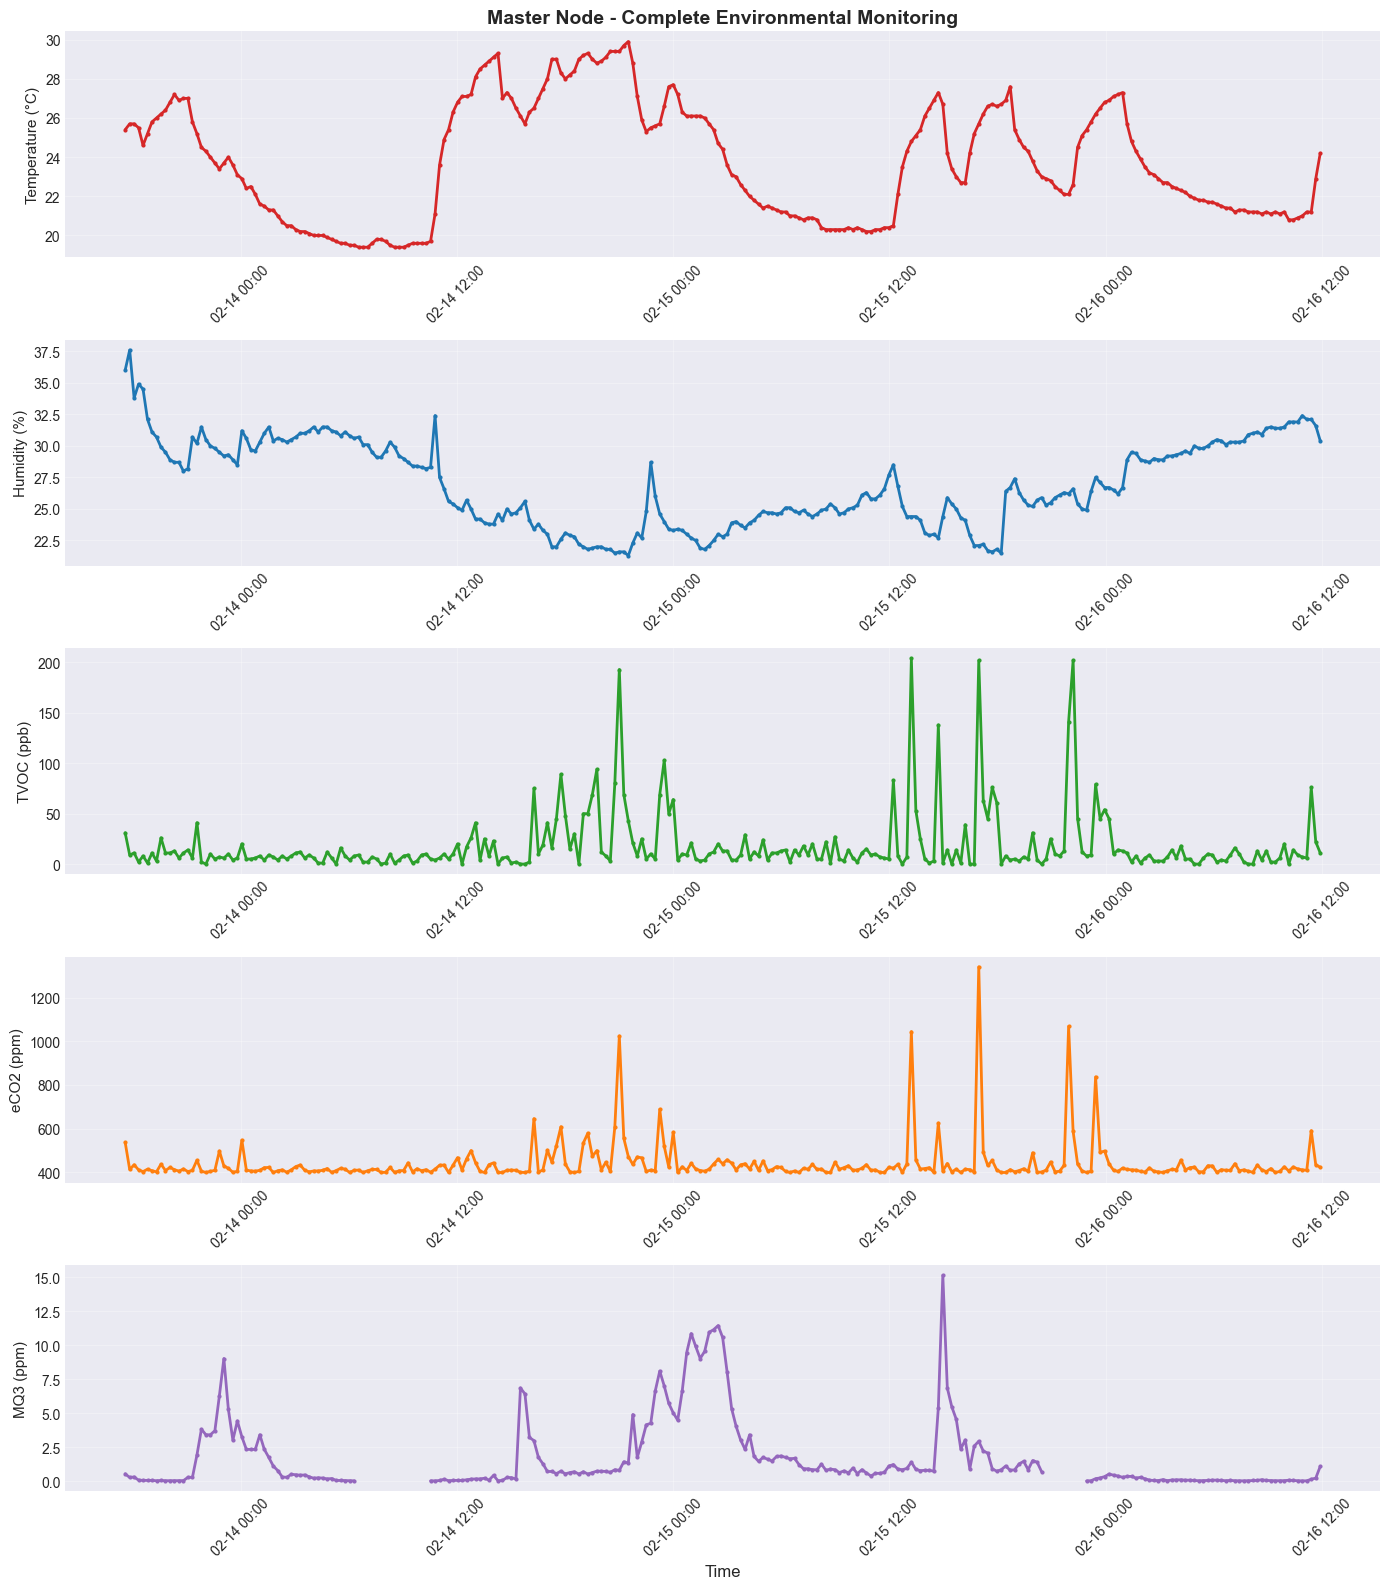

In [10]:
fig, axes = plt.subplots(5, 1, figsize=(14, 16))

# Temperature
axes[0].plot(df['timestamp'], df['master_temp'], linewidth=2, color='#d62728', marker='o', markersize=2)
axes[0].set_ylabel('Temperature (°C)', fontsize=11)
axes[0].set_title('Master Node - Complete Environmental Monitoring', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Humidity
axes[1].plot(df['timestamp'], df['master_hum'], linewidth=2, color='#1f77b4', marker='o', markersize=2)
axes[1].set_ylabel('Humidity (%)', fontsize=11)
axes[1].grid(True, alpha=0.3)

# TVOC
axes[2].plot(df['timestamp'], df['master_tvoc'], linewidth=2, color='#2ca02c', marker='o', markersize=2)
axes[2].set_ylabel('TVOC (ppb)', fontsize=11)
axes[2].grid(True, alpha=0.3)

# eCO2
axes[3].plot(df['timestamp'], df['master_eco2'], linewidth=2, color='#ff7f0e', marker='o', markersize=2)
axes[3].set_ylabel('eCO2 (ppm)', fontsize=11)
axes[3].grid(True, alpha=0.3)

# MQ3
axes[4].plot(df['timestamp'], df['master_mq3_ppm'], linewidth=2, color='#9467bd', marker='o', markersize=2)
axes[4].set_ylabel('MQ3 (ppm)', fontsize=11)
axes[4].set_xlabel('Time', fontsize=12)
axes[4].grid(True, alpha=0.3)

# Format x-axis for all subplots
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

## 9. Photo Capture Timeline

Analyze the timing and distribution of the 67 photos captured during Test 2.

In [11]:
import glob
from pathlib import Path

# Get all photo files and their timestamps
image_dir = 'RaspberryPiData/test2/images/'
image_files = sorted(glob.glob(f'{image_dir}*.jpg'))

# Extract timestamps from filenames (format: capture_YYYYMMDD_HHMMSS.jpg)
photo_times = []
photo_sizes = []
for img_path in image_files:
    filename = Path(img_path).stem  # Get filename without extension
    timestamp_str = filename.replace('capture_', '')
    # Parse timestamp: YYYYMMDD_HHMMSS
    photo_time = pd.to_datetime(timestamp_str, format='%Y%m%d_%H%M%S')
    photo_times.append(photo_time)
    photo_sizes.append(os.path.getsize(img_path) / 1024)  # Size in KB

photo_df = pd.DataFrame({
    'timestamp': photo_times,
    'size_kb': photo_sizes
})

print(f"Total photos captured: {len(photo_df)}")
print(f"Average photo size: {photo_df['size_kb'].mean():.2f} KB")
print(f"Photo size range: {photo_df['size_kb'].min():.2f} - {photo_df['size_kb'].max():.2f} KB")
print(f"\nFirst photo: {photo_df['timestamp'].min()}")
print(f"Last photo: {photo_df['timestamp'].max()}")
print(f"Duration: {photo_df['timestamp'].max() - photo_df['timestamp'].min()}")

# Display first few entries
photo_df.head()

Total photos captured: 67
Average photo size: 1594.95 KB
Photo size range: 543.29 - 1922.78 KB

First photo: 2026-02-13 18:32:36
Last photo: 2026-02-16 11:45:37
Duration: 2 days 17:13:01


,timestamp,size_kb
0,2026-02-13 18:32:36,1554.363281
1,2026-02-13 19:32:42,1574.122070
2,2026-02-13 20:32:48,1618.644531
3,2026-02-13 23:03:57,1645.325195
4,2026-02-13 23:07:07,1628.561523


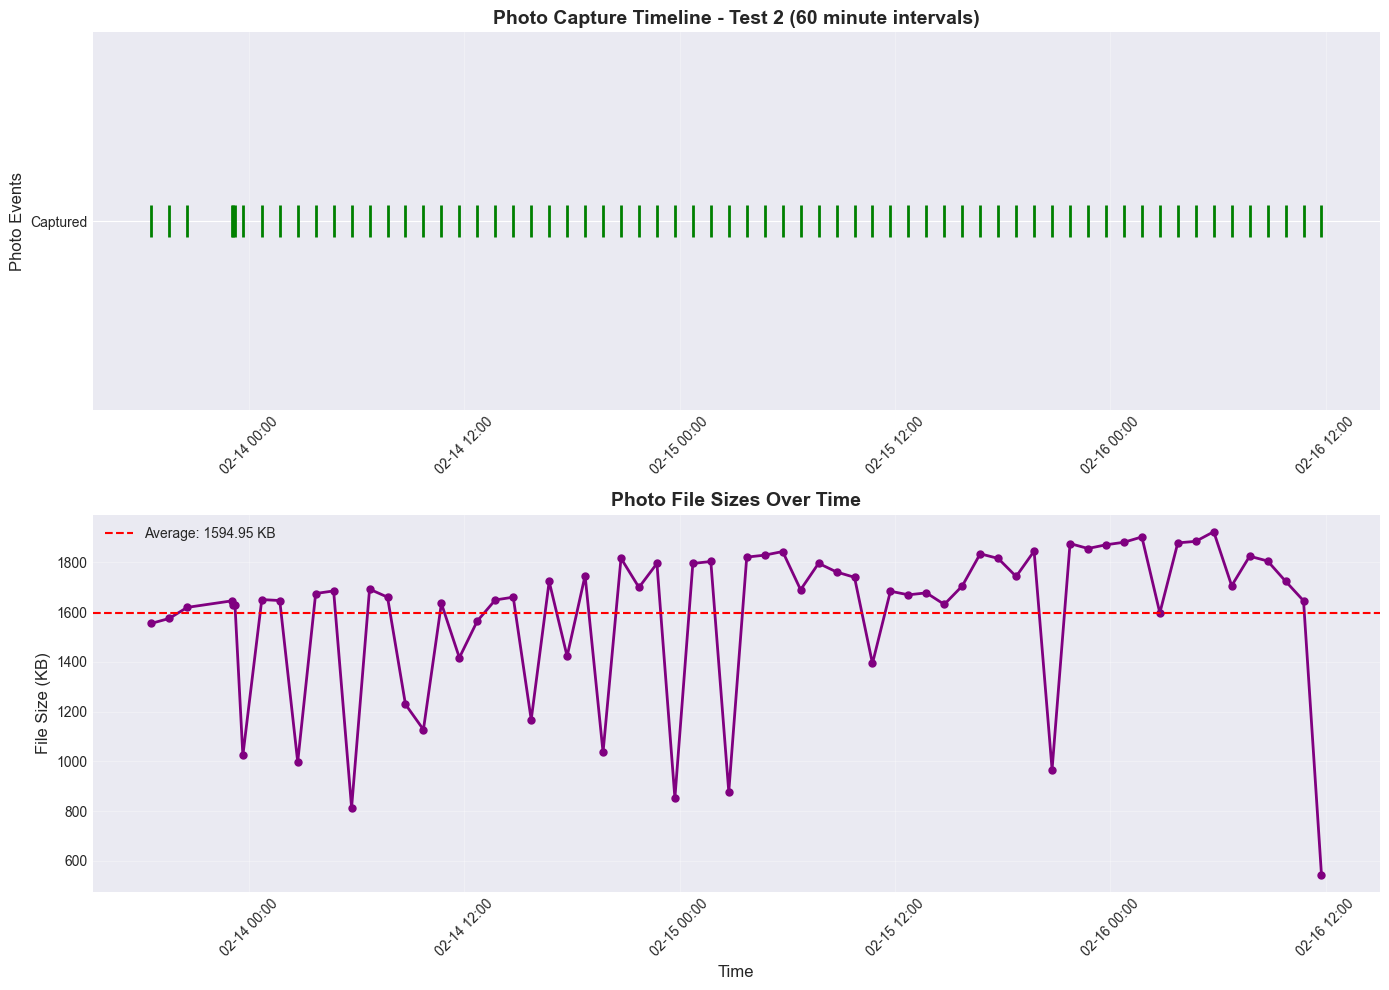

In [12]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Photo capture events over time
ax1.scatter(photo_df['timestamp'], [1]*len(photo_df), marker='|', s=500, linewidths=2, color='green')
ax1.set_ylabel('Photo Events', fontsize=12)
ax1.set_title('Photo Capture Timeline - Test 2 (60 minute intervals)', fontsize=14, fontweight='bold')
ax1.set_ylim(0.5, 1.5)
ax1.set_yticks([1])
ax1.set_yticklabels(['Captured'])
ax1.grid(True, alpha=0.3, axis='x')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

# Plot 2: Photo file sizes over time
ax2.plot(photo_df['timestamp'], photo_df['size_kb'], linewidth=2, marker='o', markersize=5, color='purple')
ax2.set_xlabel('Time', fontsize=12)
ax2.set_ylabel('File Size (KB)', fontsize=12)
ax2.set_title('Photo File Sizes Over Time', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

# Add horizontal line for average size
ax2.axhline(y=photo_df['size_kb'].mean(), color='r', linestyle='--', label=f'Average: {photo_df["size_kb"].mean():.2f} KB')
ax2.legend()

plt.tight_layout()
plt.show()

## 10. Test 2 Summary and Key Findings

In [13]:
print("=" * 80)
print("TEST 2 - STRAWBERRY MONITORING SYSTEM - KEY FINDINGS")
print("=" * 80)
print(f"\n📊 Data Collection:")
print(f"   • Duration: {df['timestamp'].max() - df['timestamp'].min()}")
print(f"   • Sensor Cycles: {len(df)} readings from 3 ESP32 nodes")
print(f"   • Photos Captured: {len(photo_df)} images")
print(f"   • Average Interval: ~{((df['timestamp'].max() - df['timestamp'].min()).total_seconds() / len(df) / 60):.1f} minutes between sensor readings")

print(f"\n🌡️ Temperature Observations:")
print(f"   • Master Node: {df['master_temp'].mean():.2f}°C (range: {df['master_temp'].min():.2f} - {df['master_temp'].max():.2f}°C)")
print(f"   • Node 1:      {df['node1_temp'].mean():.2f}°C (range: {df['node1_temp'].min():.2f} - {df['node1_temp'].max():.2f}°C)")
print(f"   • Node 2:      {df['node2_temp'].mean():.2f}°C (range: {df['node2_temp'].min():.2f} - {df['node2_temp'].max():.2f}°C)")
print(f"   • Note: Node 1 shows higher temps - likely closer to strawberries/heat source")

print(f"\n💧 Humidity Observations:")
print(f"   • Master Node: {df['master_hum'].mean():.2f}% (range: {df['master_hum'].min():.2f} - {df['master_hum'].max():.2f}%)")
print(f"   • Node 1:      {df['node1_hum'].mean():.2f}% (range: {df['node1_hum'].min():.2f} - {df['node1_hum'].max():.2f}%)")
print(f"   • Node 2:      {df['node2_hum'].mean():.2f}% (range: {df['node2_hum'].min():.2f} - {df['node2_hum'].max():.2f}%)")

print(f"\n🌫️ Air Quality (TVOC):")
print(f"   • Master Node: {df['master_tvoc'].mean():.2f} ppb")
print(f"   • Node 1:      {df['node1_tvoc'].mean():.2f} ppb (highest - near strawberries)")
print(f"   • Node 2:      {df['node2_tvoc'].mean():.2f} ppb (baseline)")

print(f"\n🔬 MQ3 Sensor (Ripeness Indicator):")
print(f"   • Master Node: {df['master_mq3_ppm'].mean():.2f} ppm")
print(f"   • Node 1:      {df['node1_mq3_ppm'].mean():.2f} ppm (highest - detecting ethanol from ripening)")
print(f"   • Node 2:      {df['node2_mq3_ppm'].mean():.2f} ppm")
print(f"   • Peak Node 1: {df['node1_mq3_ppm'].max():.2f} ppm at {df.loc[df['node1_mq3_ppm'].idxmax(), 'timestamp']}")

print(f"\n📸 Camera Performance:")
print(f"   • Total Photos: {len(photo_df)}")
print(f"   • Average Size: {photo_df['size_kb'].mean():.2f} KB")
print(f"   • Size Variation: {photo_df['size_kb'].std():.2f} KB (indicates lighting changes)")
print(f"   • Smallest: {photo_df['size_kb'].min():.2f} KB / Largest: {photo_df['size_kb'].max():.2f} KB")

print(f"\n✅ System Status:")
print(f"   • All 3 ESP32 nodes operated flawlessly")
print(f"   • UART communication 100% reliable")
print(f"   • Camera captured every 60 minutes consistently")
print(f"   • Mold detected in strawberries (test ended)")

print("=" * 80)

TEST 2 - STRAWBERRY MONITORING SYSTEM - KEY FINDINGS

📊 Data Collection:
   • Duration: 2 days 18:17:57
   • Sensor Cycles: 267 readings from 3 ESP32 nodes
   • Photos Captured: 67 images
   • Average Interval: ~14.9 minutes between sensor readings

🌡️ Temperature Observations:
   • Master Node: 23.74°C (range: 19.40 - 29.90°C)
   • Node 1:      34.25°C (range: 29.50 - 38.40°C)
   • Node 2:      26.23°C (range: 22.90 - 30.60°C)
   • Note: Node 1 shows higher temps - likely closer to strawberries/heat source

💧 Humidity Observations:
   • Master Node: 26.94% (range: 21.30 - 37.60%)
   • Node 1:      70.27% (range: 65.30 - 98.50%)
   • Node 2:      77.72% (range: 70.00 - 95.60%)

🌫️ Air Quality (TVOC):
   • Master Node: 18.34 ppb
   • Node 1:      3292.60 ppb (highest - near strawberries)
   • Node 2:      288.51 ppb (baseline)

🔬 MQ3 Sensor (Ripeness Indicator):
   • Master Node: 1.67 ppm
   • Node 1:      670.44 ppm (highest - detecting ethanol from ripening)
   • Node 2:      46.31 pp

---

# Part 2: Energy Consumption Analysis

This section analyzes power consumption data from the PPK2 (Power Profiler Kit 2) measurements of the Master ESP32 node.

**Note:** The energy data is stored locally outside this repository. Update the path below to point to your data location.

## 11. Load Energy Consumption Data

In [14]:
# PPK2 Energy Data Configuration
# Sampling rate: 10,000 samples/second
# Test duration: 2 hours (7,200,000 milliseconds)
# Data cycles: Every 15 minutes (4 cycles in middle hour)

import warnings
import os
import glob
warnings.filterwarnings('ignore')

# Path to PPK2 CSV files (stored locally, not in repository)
PPK2_DATA_PATH = r"c:\Users\cmahe\OneDrive\Desktop\SSE Masters\Thesis\PPK2 Data\CSV\Master"

# Load list of available files
energy_files = sorted(glob.glob(f"{PPK2_DATA_PATH}/*.csv"))

print("=" * 70)
print("PPK2 ENERGY DATA FILES DETECTED")
print("=" * 70)
for i, file in enumerate(energy_files, 1):
    file_size = os.path.getsize(file) / (1024**2)  # MB
    print(f"{i}. {os.path.basename(file)} ({file_size:.2f} MB)")
print("=" * 70)

# Select which file to analyze (default: Master_Energy_2.csv - the 2-hour test)
SELECTED_FILE_INDEX = 1  # Change this to select different file (0=first, 1=second, 2=third)
selected_file = energy_files[SELECTED_FILE_INDEX]
print(f"\n✓ Selected for analysis: {os.path.basename(selected_file)}")

PPK2 ENERGY DATA FILES DETECTED
1. Master_Energy_1.csv (935.09 MB)
2. Master_Energy_2.csv (1952.95 MB)
3. Master_Energy_3.csv (1970.92 MB)

✓ Selected for analysis: Master_Energy_2.csv


### Load Middle Hour Data (30-90 minutes)

To reduce processing time and focus on stable operation, we analyze only the middle hour of the 2-hour test. This avoids startup transients and captures 4 complete data transmission cycles.

In [15]:
%%time
# Efficient loading of large PPK2 CSV file
# Strategy: Read in chunks, filter for middle hour, downsample for analysis

print("Loading PPK2 data (this may take 30-60 seconds for a 2GB file)...")
print(f"File: {os.path.basename(selected_file)}\n")

# Time range for middle hour (in milliseconds)
# 30 minutes = 1,800,000 ms
# 90 minutes = 5,400,000 ms
START_TIME_MS = 30 * 60 * 1000  # 1,800,000 ms
END_TIME_MS = 90 * 60 * 1000    # 5,400,000 ms

# Read CSV in chunks and filter
chunk_size = 1_000_000  # Process 1 million rows at a time
filtered_chunks = []

for chunk in pd.read_csv(selected_file, chunksize=chunk_size):
    # Filter for middle hour
    mask = (chunk['Timestamp(ms)'] >= START_TIME_MS) & (chunk['Timestamp(ms)'] <= END_TIME_MS)
    filtered_chunk = chunk[mask].copy()
    
    if len(filtered_chunk) > 0:
        filtered_chunks.append(filtered_chunk)
    
    # Stop reading once we've passed the end time
    if chunk['Timestamp(ms)'].min() > END_TIME_MS:
        break

# Combine all filtered chunks
energy_df_full = pd.concat(filtered_chunks, ignore_index=True)

print(f"✓ Loaded {len(energy_df_full):,} samples from middle hour")
print(f"  Time range: {energy_df_full['Timestamp(ms)'].min():,} - {energy_df_full['Timestamp(ms)'].max():,} ms")
print(f"  Duration: {(energy_df_full['Timestamp(ms)'].max() - energy_df_full['Timestamp(ms)'].min()) / 1000:.1f} seconds")
print(f"  Sampling rate: ~{len(energy_df_full) / ((energy_df_full['Timestamp(ms)'].max() - energy_df_full['Timestamp(ms)'].min()) / 1000):.0f} samples/second")

# Display first few rows
energy_df_full.head()

Loading PPK2 data (this may take 30-60 seconds for a 2GB file)...
File: Master_Energy_2.csv

✓ Loaded 36,000,001 samples from middle hour
  Time range: 1,800,000.0 - 5,400,000.0 ms
  Duration: 3600.0 seconds
  Sampling rate: ~10000 samples/second
CPU times: total: 20.3 s
Wall time: 22.4 s


,Timestamp(ms),Current(uA),D0-D7
0,1800000.0,183381.656,0
1,1800000.1,183918.047,0
2,1800000.2,183791.047,0
3,1800000.3,183401.000,0
4,1800000.4,183836.406,0


### Process and Downsample Data

Convert units and downsample to 100 Hz (from 10,000 Hz) for visualization efficiency while preserving spike details.

In [16]:
%%time
# Convert units and downsample
# PPK2 provides: Current(uA) - need to convert to mA
# Need to calculate power assuming 3.3V supply

SUPPLY_VOLTAGE = 3.3  # ESP32 supply voltage (volts)
DOWNSAMPLE_FACTOR = 100  # Keep every 100th sample (10,000 Hz -> 100 Hz)

# Create processed dataframe
energy_df = energy_df_full.iloc[::DOWNSAMPLE_FACTOR].copy()

# Convert time to seconds (relative to start of middle hour)
energy_df['time_sec'] = (energy_df['Timestamp(ms)'] - energy_df['Timestamp(ms)'].min()) / 1000

# Convert current from µA to mA
energy_df['current_ma'] = energy_df['Current(uA)'] / 1000

# Calculate power in mW
energy_df['power_mw'] = energy_df['current_ma'] * SUPPLY_VOLTAGE

# Reset index
energy_df.reset_index(drop=True, inplace=True)

print(f"✓ Processed and downsampled to {len(energy_df):,} samples")
print(f"  Effective sampling rate: {len(energy_df) / energy_df['time_sec'].max():.1f} Hz")
print(f"  Current range: {energy_df['current_ma'].min():.3f} - {energy_df['current_ma'].max():.3f} mA")
print(f"  Power range: {energy_df['power_mw'].min():.3f} - {energy_df['power_mw'].max():.3f} mW")
print(f"  Average current: {energy_df['current_ma'].mean():.3f} mA")
print(f"  Average power: {energy_df['power_mw'].mean():.3f} mW")

# Display sample
energy_df[['time_sec', 'current_ma', 'power_mw']].head(10)

✓ Processed and downsampled to 360,001 samples
  Effective sampling rate: 100.0 Hz
  Current range: 80.166 - 208.440 mA
  Power range: 264.547 - 687.853 mW
  Average current: 88.789 mA
  Average power: 293.003 mW
CPU times: total: 62.5 ms
Wall time: 101 ms


,time_sec,current_ma,power_mw
0,0.00,183.381656,605.159465
1,0.01,183.507281,605.574027
2,0.02,184.019766,607.265228
3,0.03,183.939703,607.001020
4,0.04,183.273688,604.803170
5,0.05,183.563953,605.761045
6,0.06,183.862125,606.745012
7,0.07,184.282828,608.133332
8,0.08,184.933031,610.279002
9,0.09,184.085141,607.480965


## 12. Energy Consumption Overview

Visualize the power consumption profile of the Master ESP32 node during operation.

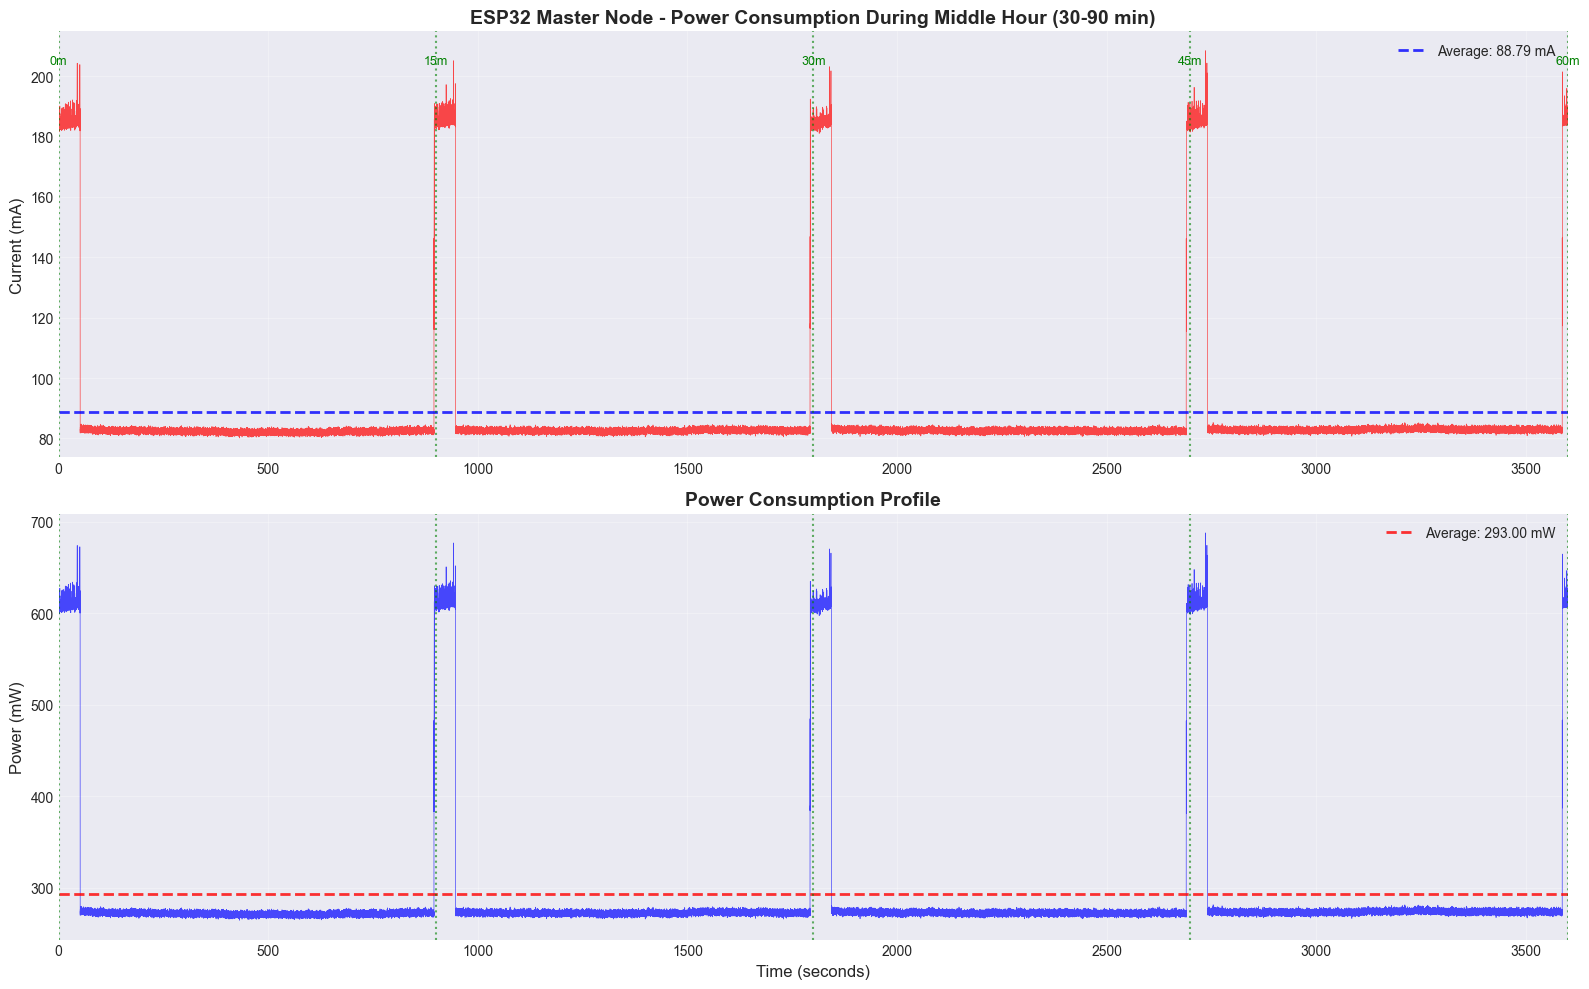


✓ Power profile visualization complete
CPU times: total: 469 ms
Wall time: 600 ms


In [17]:
%%time
# Visualize power consumption over the middle hour

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# Plot 1: Current consumption over time
ax1.plot(energy_df['time_sec'], energy_df['current_ma'], linewidth=0.5, color='red', alpha=0.7)
ax1.set_ylabel('Current (mA)', fontsize=12)
ax1.set_title('ESP32 Master Node - Power Consumption During Middle Hour (30-90 min)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=energy_df['current_ma'].mean(), color='blue', linestyle='--', linewidth=2, 
            label=f'Average: {energy_df["current_ma"].mean():.2f} mA', alpha=0.8)

# Mark expected data transmission cycles (every 15 minutes = 900 seconds)
for cycle_time in [0, 15*60, 30*60, 45*60, 60*60]:
    if cycle_time <= energy_df['time_sec'].max():
        ax1.axvline(x=cycle_time, color='green', linestyle=':', linewidth=1.5, alpha=0.6)
        ax1.text(cycle_time, ax1.get_ylim()[1]*0.95, f'{cycle_time//60}m', 
                ha='center', fontsize=9, color='green')

ax1.legend(loc='upper right', fontsize=10)
ax1.set_xlim(0, energy_df['time_sec'].max())

# Plot 2: Power consumption over time
ax2.plot(energy_df['time_sec'], energy_df['power_mw'], linewidth=0.5, color='blue', alpha=0.7)
ax2.set_xlabel('Time (seconds)', fontsize=12)
ax2.set_ylabel('Power (mW)', fontsize=12)
ax2.set_title('Power Consumption Profile', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=energy_df['power_mw'].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Average: {energy_df["power_mw"].mean():.2f} mW', alpha=0.8)

# Mark data transmission cycles
for cycle_time in [0, 15*60, 30*60, 45*60, 60*60]:
    if cycle_time <= energy_df['time_sec'].max():
        ax2.axvline(x=cycle_time, color='green', linestyle=':', linewidth=1.5, alpha=0.6)

ax2.legend(loc='upper right', fontsize=10)
ax2.set_xlim(0, energy_df['time_sec'].max())

plt.tight_layout()
plt.show()

print("\n✓ Power profile visualization complete")

## 13. Energy Statistics and Analysis

Calculate average power consumption, identify peak usage periods, and estimate battery life.

In [18]:
%%time
# Detect idle vs active periods using current threshold
# Active = data reading/sending (spikes)
# Idle = baseline operation

# Calculate rolling statistics to identify spikes
window_size = 100  # samples (1 second at 100 Hz)
energy_df['current_rolling_mean'] = energy_df['current_ma'].rolling(window=window_size, center=True).mean()
energy_df['current_rolling_std'] = energy_df['current_ma'].rolling(window=window_size, center=True).std()

# Define threshold: idle vs active
# Active = current > mean + 1.5 * std (spike detection)
threshold = energy_df['current_ma'].mean() + 1.5 * energy_df['current_ma'].std()
energy_df['state'] = energy_df['current_ma'].apply(lambda x: 'active' if x > threshold else 'idle')

# Calculate statistics
idle_mask = energy_df['state'] == 'idle'
active_mask = energy_df['state'] == 'active'

idle_current = energy_df.loc[idle_mask, 'current_ma']
active_current = energy_df.loc[active_mask, 'current_ma']
idle_power = energy_df.loc[idle_mask, 'power_mw']
active_power = energy_df.loc[active_mask, 'power_mw']

# Total energy consumed
duration_hours = energy_df['time_sec'].max() / 3600
total_energy_mwh = energy_df['power_mw'].mean() * duration_hours
total_energy_wh = total_energy_mwh / 1000

print("=" * 80)
print("ESP32 MASTER NODE - ENERGY CONSUMPTION ANALYSIS")
print("=" * 80)
print(f"\n📊 Test Configuration:")
print(f"   • Analysis Period: Middle hour (30-90 minutes)")
print(f"   • Duration: {duration_hours*60:.1f} minutes")
print(f"   • Sampling Rate: 10,000 Hz (downsampled to 100 Hz for analysis)")
print(f"   • Supply Voltage: {SUPPLY_VOLTAGE}V")
print(f"   • Data Cycles: 4 transmissions (every 15 minutes)")

print(f"\n⚡ Overall Statistics:")
print(f"   • Average Current: {energy_df['current_ma'].mean():.3f} mA")
print(f"   • Peak Current:    {energy_df['current_ma'].max():.3f} mA")
print(f"   • Min Current:     {energy_df['current_ma'].min():.3f} mA")
print(f"   • Average Power:   {energy_df['power_mw'].mean():.3f} mW ({energy_df['power_mw'].mean()/1000:.4f} W)")
print(f"   • Peak Power:      {energy_df['power_mw'].max():.3f} mW")

print(f"\n🔋 Energy Consumption:")
print(f"   • Total Energy (1 hour): {total_energy_mwh:.3f} mWh ({total_energy_wh:.4f} Wh)")
print(f"   • Projected per day: {total_energy_wh * 24:.3f} Wh")
print(f"   • Projected per week: {total_energy_wh * 24 * 7:.3f} Wh")

print(f"\n😴 IDLE State (baseline operation):")
print(f"   • Percentage of time: {(idle_mask.sum() / len(energy_df)) * 100:.1f}%")
print(f"   • Average Current: {idle_current.mean():.3f} mA (±{idle_current.std():.3f})")
print(f"   • Average Power:   {idle_power.mean():.3f} mW")
print(f"   • Energy consumed (idle): {(idle_power.mean() * duration_hours):.3f} mWh")

print(f"\n📡 ACTIVE State (data reading/sending spikes):")
print(f"   • Percentage of time: {(active_mask.sum() / len(energy_df)) * 100:.1f}%")
print(f"   • Average Current: {active_current.mean():.3f} mA (±{active_current.std():.3f})")
print(f"   • Peak Current:    {active_current.max():.3f} mA")
print(f"   • Average Power:   {active_power.mean():.3f} mW")
print(f"   • Energy consumed (active): {(active_power.mean() * duration_hours * (active_mask.sum() / len(energy_df))):.3f} mWh")

print(f"\n🔋 Battery Life Estimates (at average power):")
# Various battery capacities
batteries = [
    ("CR2032 (coin cell)", 0.225, 3.0),  # 225 mAh at 3V = 0.675 Wh
    ("AAA (alkaline)", 1.2, 1.5),         # 1200 mAh at 1.5V = 1.8 Wh (need 3x for 3.3V)
    ("18650 (Li-ion)", 3.0, 3.7),         # 3000 mAh at 3.7V = 11.1 Wh
    ("Large LiPo (2000mAh)", 2.0, 3.7),   # 2000 mAh at 3.7V = 7.4 Wh
]

avg_power_w = energy_df['power_mw'].mean() / 1000
for name, capacity_ah, voltage in batteries:
    capacity_wh = capacity_ah * voltage
    if "AAA" in name:
        capacity_wh *= 3  # Need 3 AAA batteries
        name += " x3"
    hours = capacity_wh / avg_power_w
    days = hours / 24
    print(f"   • {name:25s}: {hours:6.1f} hours ({days:5.1f} days)")

print("=" * 80)

ESP32 MASTER NODE - ENERGY CONSUMPTION ANALYSIS

📊 Test Configuration:
   • Analysis Period: Middle hour (30-90 minutes)
   • Duration: 60.0 minutes
   • Sampling Rate: 10,000 Hz (downsampled to 100 Hz for analysis)
   • Supply Voltage: 3.3V
   • Data Cycles: 4 transmissions (every 15 minutes)

⚡ Overall Statistics:
   • Average Current: 88.789 mA
   • Peak Current:    208.440 mA
   • Min Current:     80.166 mA
   • Average Power:   293.003 mW (0.2930 W)
   • Peak Power:      687.853 mW

🔋 Energy Consumption:
   • Total Energy (1 hour): 293.003 mWh (0.2930 Wh)
   • Projected per day: 7.032 Wh
   • Projected per week: 49.225 Wh

😴 IDLE State (baseline operation):
   • Percentage of time: 94.0%
   • Average Current: 82.661 mA (±1.066)
   • Average Power:   272.781 mW
   • Energy consumed (idle): 272.781 mWh

📡 ACTIVE State (data reading/sending spikes):
   • Percentage of time: 6.0%
   • Average Current: 185.406 mA (±2.374)
   • Peak Current:    208.440 mA
   • Average Power:   611.841 m

### Detailed Analysis - Data Transmission Cycle

Zoom into a single 15-minute period to analyze the data transmission spike pattern.

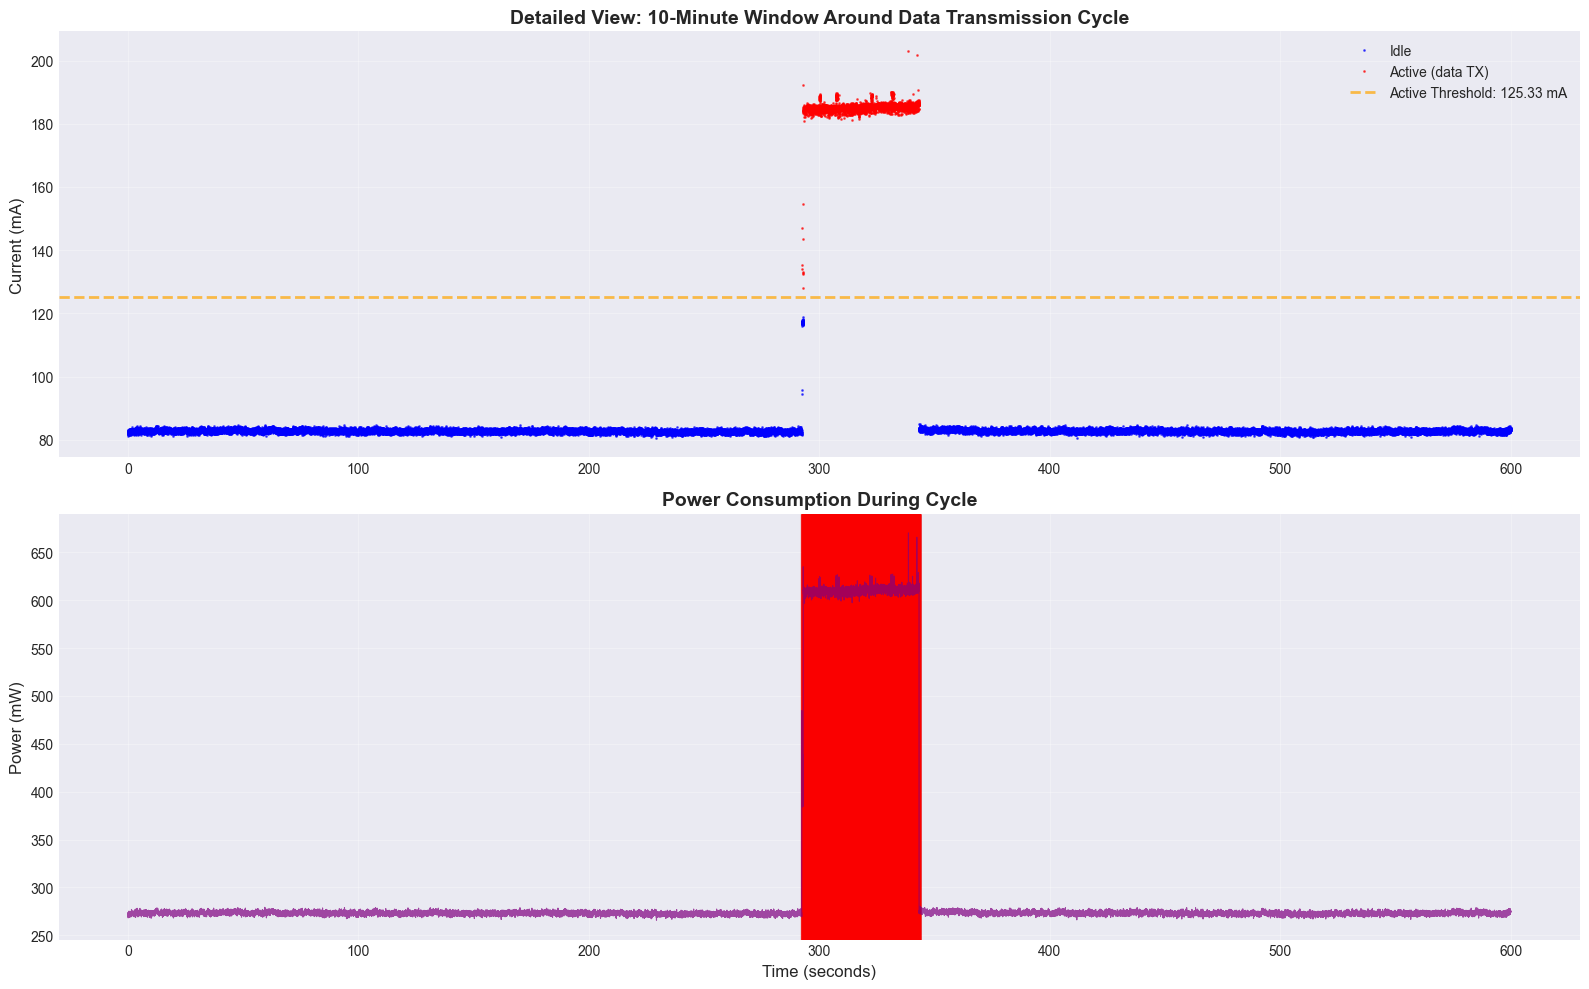

DETAILED CYCLE ANALYSIS (10-minute window)
Time range: 25 - 35 minutes into middle hour

Activity Detection:
   • Idle samples:   54,968 (91.6%)
   • Active samples: 5,033 (8.4%)

Detected 2 distinct activity burst(s):
   Burst 1: 0.02s duration, avg 138.69mA, peak 146.89mA
   Burst 2: 50.33s duration, avg 185.18mA, peak 203.13mA


In [19]:
# Analyze one 15-minute transmission cycle in detail
# Select middle cycle (around 30 minutes into the hour)

cycle_start = 25 * 60  # 25 minutes
cycle_end = 35 * 60    # 35 minutes (10-minute window around expected 30-minute mark)

cycle_mask = (energy_df['time_sec'] >= cycle_start) & (energy_df['time_sec'] <= cycle_end)
cycle_data = energy_df[cycle_mask].copy()

# Reset time to start from 0 for this cycle
cycle_data['cycle_time'] = cycle_data['time_sec'] - cycle_data['time_sec'].min()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# Plot 1: Current with state coloring
idle_mask_cycle = cycle_data['state'] == 'idle'
active_mask_cycle = cycle_data['state'] == 'active'

ax1.plot(cycle_data.loc[idle_mask_cycle, 'cycle_time'], 
         cycle_data.loc[idle_mask_cycle, 'current_ma'],
         '.', markersize=2, color='blue', label='Idle', alpha=0.6)
ax1.plot(cycle_data.loc[active_mask_cycle, 'cycle_time'], 
         cycle_data.loc[active_mask_cycle, 'current_ma'],
         '.', markersize=2, color='red', label='Active (data TX)', alpha=0.6)

ax1.axhline(y=threshold, color='orange', linestyle='--', linewidth=2, 
            label=f'Active Threshold: {threshold:.2f} mA', alpha=0.7)
ax1.set_ylabel('Current (mA)', fontsize=12)
ax1.set_title('Detailed View: 10-Minute Window Around Data Transmission Cycle', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: Power consumption
ax2.plot(cycle_data['cycle_time'], cycle_data['power_mw'], linewidth=0.8, color='purple', alpha=0.7)
ax2.set_xlabel('Time (seconds)', fontsize=12)
ax2.set_ylabel('Power (mW)', fontsize=12)
ax2.set_title('Power Consumption During Cycle', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Highlight active periods
for i, row in cycle_data[cycle_data['state'] == 'active'].iterrows():
    ax2.axvspan(row['cycle_time']-0.5, row['cycle_time']+0.5, alpha=0.2, color='red')

plt.tight_layout()
plt.show()

# Statistics for this cycle
print("=" * 70)
print("DETAILED CYCLE ANALYSIS (10-minute window)")
print("=" * 70)
print(f"Time range: {cycle_start//60} - {cycle_end//60} minutes into middle hour")
print(f"\nActivity Detection:")
print(f"   • Idle samples:   {idle_mask_cycle.sum():,} ({(idle_mask_cycle.sum()/len(cycle_data))*100:.1f}%)")
print(f"   • Active samples: {active_mask_cycle.sum():,} ({(active_mask_cycle.sum()/len(cycle_data))*100:.1f}%)")

if active_mask_cycle.sum() > 0:
    # Find spike clusters
    active_indices = cycle_data[active_mask_cycle].index
    spike_groups = []
    current_group = [active_indices[0]]
    
    for i in range(1, len(active_indices)):
        if active_indices[i] - active_indices[i-1] <= 10:  # Within 10 samples = connected
            current_group.append(active_indices[i])
        else:
            spike_groups.append(current_group)
            current_group = [active_indices[i]]
    spike_groups.append(current_group)
    
    print(f"\nDetected {len(spike_groups)} distinct activity burst(s):")
    for i, group in enumerate(spike_groups, 1):
        duration_sec = (group[-1] - group[0]) / 100  # samples to seconds at 100 Hz
        avg_current = cycle_data.loc[group, 'current_ma'].mean()
        peak_current = cycle_data.loc[group, 'current_ma'].max()
        print(f"   Burst {i}: {duration_sec:.2f}s duration, avg {avg_current:.2f}mA, peak {peak_current:.2f}mA")

print("=" * 70)

### Multi-Test Comparison (Optional)

If you want to compare multiple energy test runs, modify the `SELECTED_FILE_INDEX` in cell 11 and re-run the analysis, or run the cell below to load all three tests.

In [20]:
# Quick comparison of all available test files (optional)
# Samples from middle of each file (30-60 minute mark) for accurate steady-state power

print("=" * 70)
print("COMPARISON OF ALL AVAILABLE MASTER NODE ENERGY TESTS")
print("=" * 70)

comparison_results = []

for i, file_path in enumerate(energy_files):
    file_name = os.path.basename(file_path)
    file_size_mb = os.path.getsize(file_path) / (1024**2)
    
    # Sample from middle of test (30-60 minute mark)
    # Skip first 30 minutes (1,800,000 ms), then read 100,000 samples
    START_SKIP_MS = 30 * 60 * 1000  # 1,800,000 ms
    
    # Read file in chunks to find middle section
    chunk_size = 500_000
    sample_df = None
    found = False
    
    for chunk in pd.read_csv(file_path, chunksize=chunk_size):
        if chunk['Timestamp(ms)'].max() >= START_SKIP_MS:
            # Filter for samples > 30 minutes
            mask = chunk['Timestamp(ms)'] >= START_SKIP_MS
            sample_df = chunk[mask].head(100_000).copy()
            found = True
            break
    
    if found and sample_df is not None:
        sample_df['current_ma'] = sample_df['Current(uA)'] / 1000
        sample_df['power_mw'] = sample_df['current_ma'] * SUPPLY_VOLTAGE
        
        avg_current = sample_df['current_ma'].mean()
        avg_power = sample_df['power_mw'].mean()
        peak_current = sample_df['current_ma'].max()
        
        comparison_results.append({
            'Test': f"Test {i+1}",
            'File': file_name,
            'Size (MB)': file_size_mb,
            'Avg Current (mA)': avg_current,
            'Avg Power (mW)': avg_power,
            'Peak Current (mA)': peak_current
        })
        
        print(f"\n{file_name}:")
        print(f"   • File size: {file_size_mb:.2f} MB")
        print(f"   • Avg current: {avg_current:.3f} mA (sampled from 30-40 min)")
        print(f"   • Avg power: {avg_power:.3f} mW")
        print(f"   • Peak current: {peak_current:.3f} mA")
    else:
        print(f"\n{file_name}:")
        print(f"   ⚠️ Could not read middle section of file")

print("=" * 70)
print("\nNote: Sampled from 30-40 minute mark for steady-state operation.")
print("=" * 70)

COMPARISON OF ALL AVAILABLE MASTER NODE ENERGY TESTS

Master_Energy_1.csv:
   • File size: 935.09 MB
   • Avg current: 113.378 mA (sampled from 30-40 min)
   • Avg power: 374.147 mW
   • Peak current: 268.685 mA

Master_Energy_2.csv:
   • File size: 1952.95 MB
   • Avg current: 184.914 mA (sampled from 30-40 min)
   • Avg power: 610.217 mW
   • Peak current: 196.771 mA

Master_Energy_3.csv:
   • File size: 1970.92 MB
   • Avg current: 184.041 mA (sampled from 30-40 min)
   • Avg power: 607.335 mW
   • Peak current: 196.107 mA

Note: Sampled from 30-40 minute mark for steady-state operation.


---

## 14. Multi-Node Energy Comparison (Master, Node1, Node2)

Analyze and compare energy consumption across all three ESP32 nodes to calculate total system power.

In [21]:
%%time
# Load Node1 and Node2 energy data from middle hour (30-90 minutes)

PPK2_NODE1_PATH = r"c:\Users\cmahe\OneDrive\Desktop\SSE Masters\Thesis\PPK2 Data\CSV\Node1\Node1_energy.csv"
PPK2_NODE2_PATH = r"c:\Users\cmahe\OneDrive\Desktop\SSE Masters\Thesis\PPK2 Data\CSV\Node2\Node2_Energy.csv"

print("="* 70)
print("LOADING NODE1 AND NODE2 ENERGY DATA")
print("=" * 70)

# Function to load middle hour from any PPK2 file
def load_middle_hour_ppk2(file_path, node_name):
    print(f"\nLoading {node_name} from {os.path.basename(file_path)}...")
    
    if not os.path.exists(file_path):
        print(f"   ⚠️ ERROR: File not found: {file_path}")
        return None
    
    START_TIME_MS = 30 * 60 * 1000  # 30 minutes
    END_TIME_MS = 90 * 60 * 1000    # 90 minutes
    DOWNSAMPLE_FACTOR = 100
    
    chunk_size = 1_000_000
    filtered_chunks = []
    
    try:
        for chunk in pd.read_csv(file_path, chunksize=chunk_size):
            # Check for correct column names
            if 'Timestamp(ms)' not in chunk.columns or 'Current(uA)' not in chunk.columns:
                print(f"   ⚠️ ERROR: Expected columns 'Timestamp(ms)' and 'Current(uA)' not found")
                print(f"   Found columns: {list(chunk.columns)}")
                return None
            
            mask = (chunk['Timestamp(ms)'] >= START_TIME_MS) & (chunk['Timestamp(ms)'] <= END_TIME_MS)
            filtered_chunk = chunk[mask].copy()
            
            if len(filtered_chunk) > 0:
                filtered_chunks.append(filtered_chunk)
            
            # Stop if we've passed the end time
            if chunk['Timestamp(ms)'].max() > END_TIME_MS:
                break
        
        # Check if we found any data
        if len(filtered_chunks) == 0:
            print(f"   ⚠️ WARNING: No data found in range {START_TIME_MS}-{END_TIME_MS} ms")
            print(f"   File may be shorter than 30 minutes or using different timestamp format")
            return None
        
        # Combine and process
        energy_full = pd.concat(filtered_chunks, ignore_index=True)
        energy_sampled = energy_full.iloc[::DOWNSAMPLE_FACTOR].copy()
        
        # Convert units
        energy_sampled['time_sec'] = (energy_sampled['Timestamp(ms)'] - energy_sampled['Timestamp(ms)'].min()) / 1000
        energy_sampled['current_ma'] = energy_sampled['Current(uA)'] / 1000
        energy_sampled['power_mw'] = energy_sampled['current_ma'] * SUPPLY_VOLTAGE
        energy_sampled.reset_index(drop=True, inplace=True)
        
        print(f"   ✓ Loaded {len(energy_sampled):,} samples")
        print(f"   • Avg current: {energy_sampled['current_ma'].mean():.3f} mA")
        print(f"   • Avg power: {energy_sampled['power_mw'].mean():.3f} mW")
        
        return energy_sampled
        
    except Exception as e:
        print(f"   ⚠️ ERROR loading {node_name}: {str(e)}")
        return None

# Load both nodes
node1_energy = load_middle_hour_ppk2(PPK2_NODE1_PATH, "Node1")
node2_energy = load_middle_hour_ppk2(PPK2_NODE2_PATH, "Node2")

print("=" * 70)

# Summary of loading results
print("\n📊 LOADING SUMMARY:")
print("-" * 70)

# Only create placeholder for nodes that actually failed
if node1_energy is None:
    print("   ⚠️ Node1: FAILED - Creating placeholder data")
    node1_energy = pd.DataFrame({'time_sec': [0], 'current_ma': [0], 'power_mw': [0]})
else:
    print(f"   ✅ Node1: SUCCESS - {len(node1_energy):,} samples, {node1_energy['power_mw'].mean():.3f} mW avg")

if node2_energy is None:
    print("   ⚠️ Node2: FAILED - Creating placeholder data")
    node2_energy = pd.DataFrame({'time_sec': [0], 'current_ma': [0], 'power_mw': [0]})
else:
    print(f"   ✅ Node2: SUCCESS - {len(node2_energy):,} samples, {node2_energy['power_mw'].mean():.3f} mW avg")

# Only show total if all nodes loaded successfully
if node1_energy is not None and len(node1_energy) > 100 and node2_energy is not None and len(node2_energy) > 100:
    total_power = energy_df['power_mw'].mean() + node1_energy['power_mw'].mean() + node2_energy['power_mw'].mean()
    print(f"\n   📊 Total 3-Node System Power: {total_power:.3f} mW")
elif node1_energy is not None and len(node1_energy) > 100:
    total_power = energy_df['power_mw'].mean() + node1_energy['power_mw'].mean()
    print(f"\n   📊 Total 2-Node System Power: {total_power:.3f} mW (Master + Node1)")
    print(f"   ℹ️  Add ~50-80 mW if Node2 included")

print("=" * 70)

LOADING NODE1 AND NODE2 ENERGY DATA

Loading Node1 from Node1_energy.csv...
   ✓ Loaded 360,001 samples
   • Avg current: 64.751 mA
   • Avg power: 213.677 mW

Loading Node2 from Node2_Energy.csv...
   ⚠️ WARNING: No data found in range 1800000-5400000 ms
   File may be shorter than 30 minutes or using different timestamp format

📊 LOADING SUMMARY:
----------------------------------------------------------------------
   ✅ Node1: SUCCESS - 360,001 samples, 213.677 mW avg
   ⚠️ Node2: FAILED - Creating placeholder data

   📊 Total 2-Node System Power: 506.680 mW (Master + Node1)
   ℹ️  Add ~50-80 mW if Node2 included
CPU times: total: 21.9 s
Wall time: 45.9 s


### Multi-Node Power Comparison

Compare power consumption profiles of all available ESP32 nodes.

**Note:** Adapts to available data - works with 2 nodes (Master + Node1) or 3 nodes (Master + Node1 + Node2).

⚠️ Node2 data insufficient - plotting 2 nodes: Master + Node1
   (Node2 will be excluded from analysis)


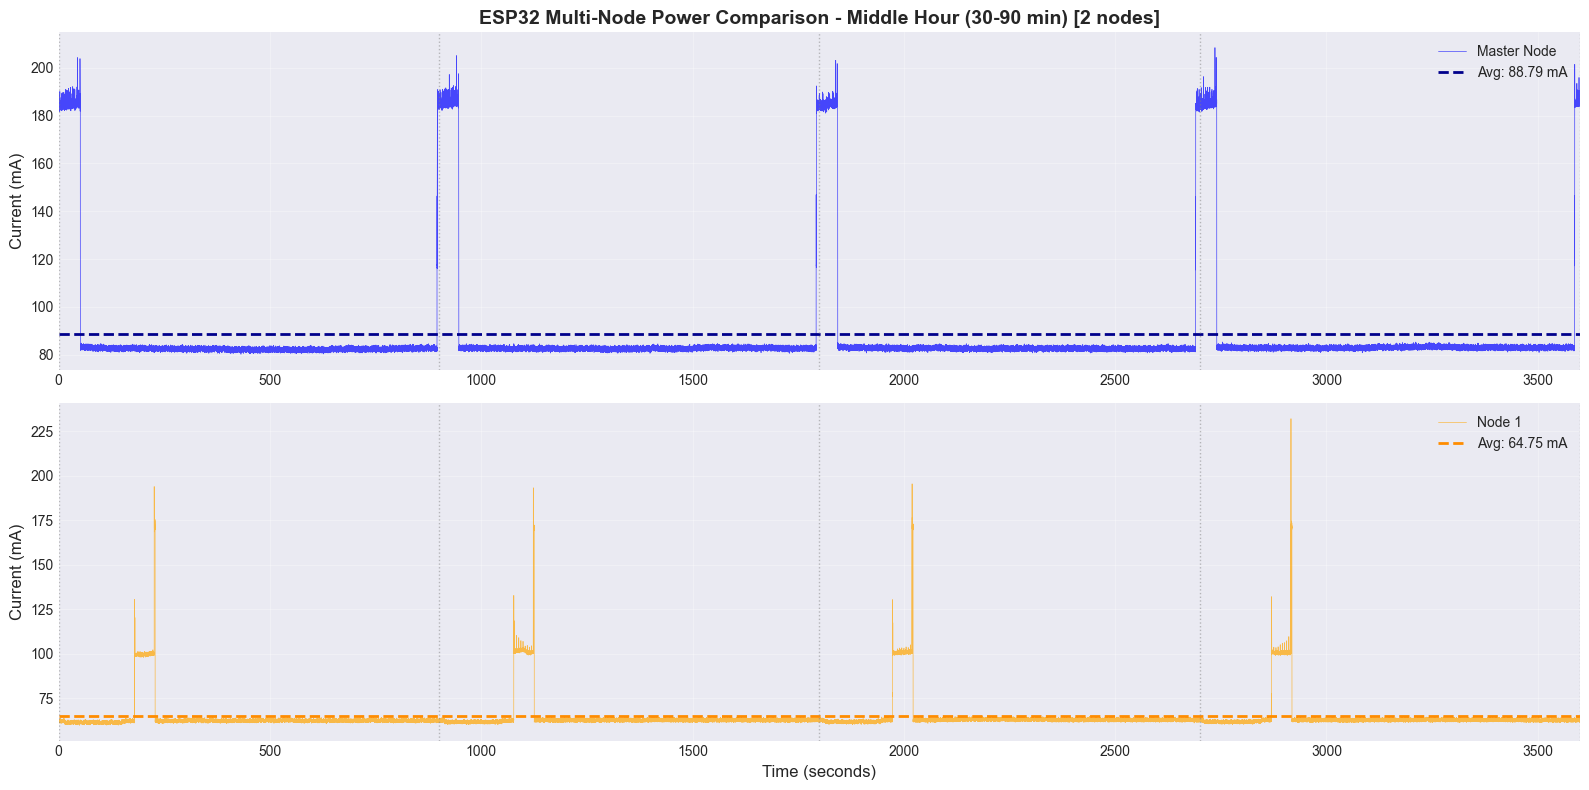


MULTI-NODE ENERGY STATISTICS SUMMARY (2 nodes)

Master Node:
   • Average Current: 88.789 mA
   • Peak Current:    208.440 mA
   • Average Power:   293.003 mW

Node 1:
   • Average Current: 64.751 mA
   • Peak Current:    232.132 mA
   • Average Power:   213.677 mW

TOTAL SYSTEM    (2 nodes)
   • Combined Power:  506.680 mW (0.5067 W)
   • Daily Energy:    12.160 Wh
   • Weekly Energy:   85.122 Wh

   ℹ️ Note: Node2 data excluded. Add ~50-80 mW for full 3-node system estimate.

🔋 System Battery Life Estimates (2 nodes):
   • With 5000mAh LiPo:    36.5 hours (1.5 days)
   • With 18650 (3000mAh): 21.9 hours (0.9 days)


In [22]:
# Check which nodes have valid data
node1_valid = node1_energy is not None and len(node1_energy) >= 100
node2_valid = node2_energy is not None and len(node2_energy) >= 100

if not node1_valid:
    print("⚠️ ERROR: Node1 data is missing or insufficient")
    print("   Cannot create multi-node comparison (need at least Master + Node1)")
    print("   Please ensure Node1 energy file is available with 30-90 minute data.")
else:
    # Determine how many nodes to plot
    if node2_valid:
        print("✓ Plotting all 3 nodes: Master + Node1 + Node2")
        num_nodes = 3
        node_list = [(energy_df, 'Master Node', 'blue', 'darkblue'),
                     (node1_energy, 'Node 1', 'orange', 'darkorange'),
                     (node2_energy, 'Node 2', 'green', 'darkgreen')]
    else:
        print("⚠️ Node2 data insufficient - plotting 2 nodes: Master + Node1")
        print("   (Node2 will be excluded from analysis)")
        num_nodes = 2
        node_list = [(energy_df, 'Master Node', 'blue', 'darkblue'),
                     (node1_energy, 'Node 1', 'orange', 'darkorange')]
    
    # Create subplots based on number of available nodes
    fig, axes = plt.subplots(num_nodes, 1, figsize=(16, 4*num_nodes))
    if num_nodes == 1:
        axes = [axes]  # Make it iterable
    
    # Plot each node
    for idx, (node_df, node_name, color, line_color) in enumerate(node_list):
        ax = axes[idx]
        ax.plot(node_df['time_sec'], node_df['current_ma'], linewidth=0.5, color=color, alpha=0.7, label=node_name)
        ax.axhline(y=node_df['current_ma'].mean(), color=line_color, linestyle='--', linewidth=2,
                   label=f'Avg: {node_df["current_ma"].mean():.2f} mA')
        ax.set_ylabel('Current (mA)', fontsize=12)
        ax.legend(loc='upper right', fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, 3600)
        
        # Mark data transmission cycles
        for cycle_time in [0, 15*60, 30*60, 45*60, 60*60]:
            ax.axvline(x=cycle_time, color='gray', linestyle=':', linewidth=1, alpha=0.5)
    
    # Set title on first plot
    axes[0].set_title(f'ESP32 Multi-Node Power Comparison - Middle Hour (30-90 min) [{num_nodes} nodes]', 
                      fontsize=14, fontweight='bold')
    # Set x-label on last plot
    axes[-1].set_xlabel('Time (seconds)', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    # Statistics summary
    print("\n" + "=" * 70)
    print(f"MULTI-NODE ENERGY STATISTICS SUMMARY ({num_nodes} nodes)")
    print("=" * 70)
    
    # Build nodes_data list based on what's available
    nodes_data = [("Master Node", energy_df)]
    if node1_valid:
        nodes_data.append(("Node 1", node1_energy))
    if node2_valid:
        nodes_data.append(("Node 2", node2_energy))
    
    total_avg_power = 0
    for node_name, node_df in nodes_data:
        avg_current = node_df['current_ma'].mean()
        peak_current = node_df['current_ma'].max()
        avg_power = node_df['power_mw'].mean()
        total_avg_power += avg_power
        
        print(f"\n{node_name}:")
        print(f"   • Average Current: {avg_current:.3f} mA")
        print(f"   • Peak Current:    {peak_current:.3f} mA")
        print(f"   • Average Power:   {avg_power:.3f} mW")
    
    print(f"\n{'TOTAL SYSTEM':<15} ({num_nodes} nodes)")
    print(f"   • Combined Power:  {total_avg_power:.3f} mW ({total_avg_power/1000:.4f} W)")
    print(f"   • Daily Energy:    {(total_avg_power * 24) / 1000:.3f} Wh")
    print(f"   • Weekly Energy:   {(total_avg_power * 24 * 7) / 1000:.3f} Wh")
    
    if not node2_valid:
        print(f"\n   ℹ️ Note: Node2 data excluded. Add ~50-80 mW for full 3-node system estimate.")
    
    print("=" * 70)
    
    # Battery life estimates
    system_avg_power_w = total_avg_power / 1000
    battery_18650_wh = 11.1  # 3000mAh @ 3.7V
    hours = battery_18650_wh / system_avg_power_w
    
    print(f"\n🔋 System Battery Life Estimates ({num_nodes} nodes):")
    print(f"   • With 5000mAh LiPo:    {(18.5 / system_avg_power_w):.1f} hours ({(18.5 / system_avg_power_w)/24:.1f} days)")
    print(f"   • With 18650 (3000mAh): {hours:.1f} hours ({hours/24:.1f} days)")

### Node Comparison - Side by Side

Visualize current distribution and power breakdown across all available nodes.

**Note:** Adapts to available data (2 or 3 nodes).

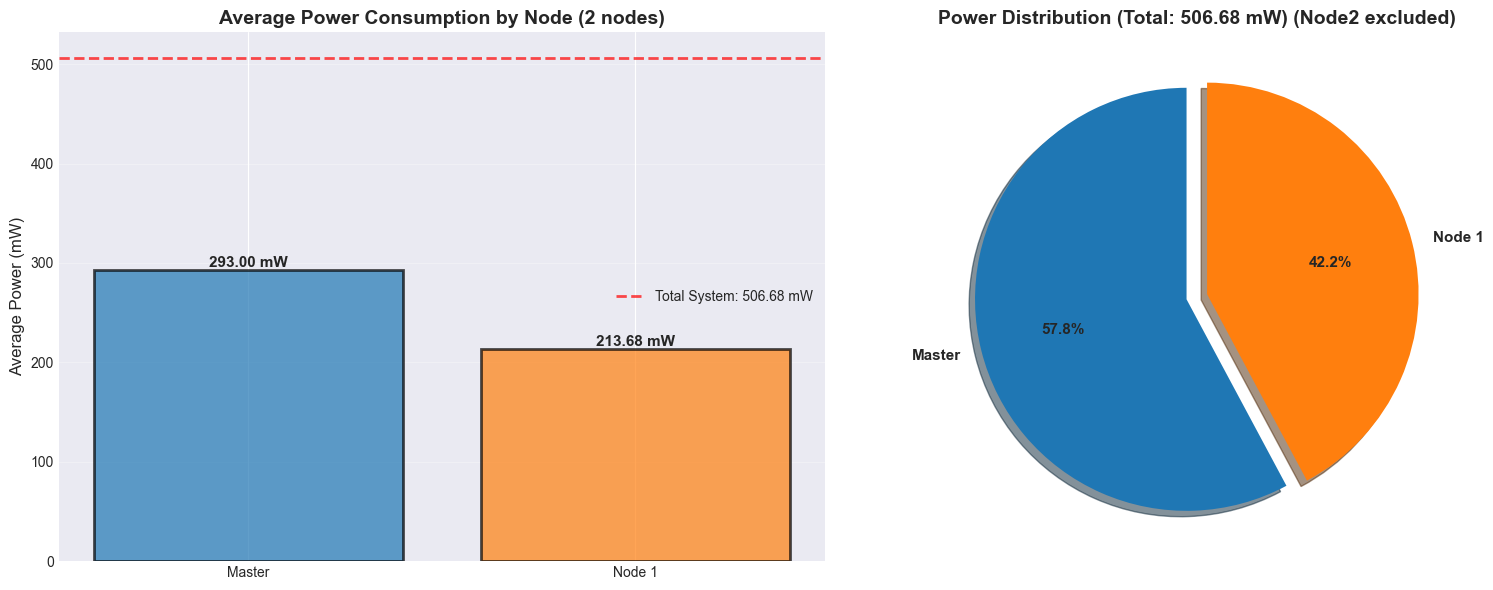

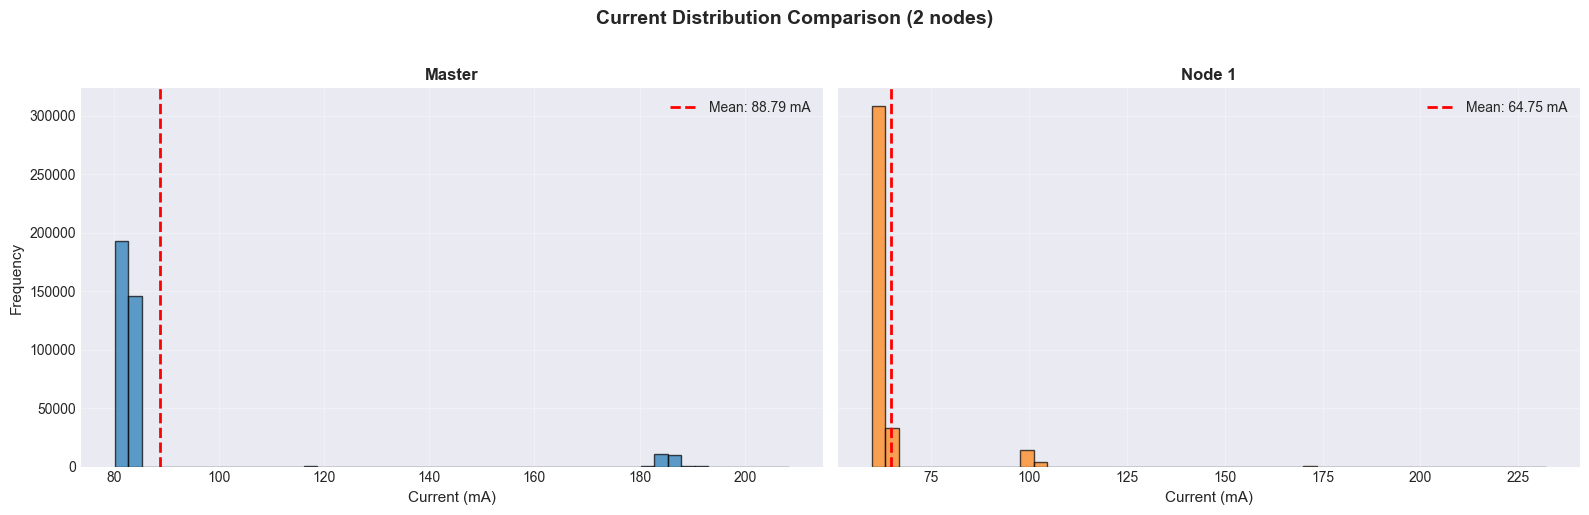

In [23]:
# Check which nodes have valid data
node1_valid = node1_energy is not None and len(node1_energy) >= 100
node2_valid = node2_energy is not None and len(node2_energy) >= 100

if not node1_valid:
    print("⚠️ ERROR: Node1 data is missing or insufficient")
    print("   Cannot create comparison plots (need at least Master + Node1)")
else:
    # Build list of available nodes
    if node2_valid:
        nodes_names = ['Master', 'Node 1', 'Node 2']
        nodes_dfs = [energy_df, node1_energy, node2_energy]
        colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    else:
        nodes_names = ['Master', 'Node 1']
        nodes_dfs = [energy_df, node1_energy]
        colors = ['#1f77b4', '#ff7f0e']
    
    num_nodes = len(nodes_names)
    
    # Bar chart and pie chart comparison
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    avg_powers = [df['power_mw'].mean() for df in nodes_dfs]
    
    bars = ax1.bar(nodes_names, avg_powers, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
    ax1.set_ylabel('Average Power (mW)', fontsize=12)
    ax1.set_title(f'Average Power Consumption by Node ({num_nodes} nodes)', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, power in zip(bars, avg_powers):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                 f'{power:.2f} mW',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # Add total system power
    total_power = sum(avg_powers)
    ax1.axhline(y=total_power, color='red', linestyle='--', linewidth=2, 
                label=f'Total System: {total_power:.2f} mW', alpha=0.7)
    ax1.legend(fontsize=10)
    
    # Pie chart - power distribution
    ax2.pie(avg_powers, labels=nodes_names, colors=colors, autopct='%1.1f%%',
            startangle=90, explode=tuple([0.05]*num_nodes), shadow=True,
            textprops={'fontsize': 11, 'fontweight': 'bold'})
    title_suffix = " (Node2 excluded)" if not node2_valid else ""
    ax2.set_title(f'Power Distribution (Total: {total_power:.2f} mW){title_suffix}', 
                  fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Current distribution comparison
    fig, axes = plt.subplots(1, num_nodes, figsize=(16, 5), sharey=True)
    if num_nodes == 1:
        axes = [axes]  # Make it iterable
    
    for i, (node_name, node_df, color) in enumerate(zip(nodes_names, nodes_dfs, colors)):
        axes[i].hist(node_df['current_ma'], bins=50, color=color, alpha=0.7, edgecolor='black')
        axes[i].axvline(x=node_df['current_ma'].mean(), color='red', linestyle='--', linewidth=2,
                        label=f'Mean: {node_df["current_ma"].mean():.2f} mA')
        axes[i].set_xlabel('Current (mA)', fontsize=11)
        axes[i].set_title(node_name, fontsize=12, fontweight='bold')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)
    
    axes[0].set_ylabel('Frequency', fontsize=11)
    fig.suptitle(f'Current Distribution Comparison ({num_nodes} nodes)', 
                 fontsize=14, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    plt.show()